# Smart School Project – ECAM 2026
## Prédiction d'échec & Correction automatique par OCR

> **Dataset 1** : `train.csv` – 630 000 étudiants, 14 features  
> **Dataset 2** : images EMNIST 28×28px – 62 classes (chiffres + lettres)

---

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)

print('Imports OK')

Imports OK


---
# PARTIE 1 : Prédiction d'échec aux examens
---

## 1.1 Chargement et exploration du dataset

In [35]:
# Adapter le chemin selon votre environnement
DATA_PATH = 'train.csv'  # ou chemin complet

df = pd.read_csv('student_dataset/student_failure/train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (630000, 15)


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


In [36]:
print('Types et valeurs manquantes:')
print(df.dtypes)
print()
print(df.isnull().sum())

Types et valeurs manquantes:
id                            int64
age                           int64
genre                           str
diplôme                         str
heures_etude                float64
assiduité_classe            float64
accès_internet                  str
heures_sommeil              float64
qualité_sommeil                 str
méthode_etude                   str
évaluation_établissement        str
difficulté_examen               str
score_examen                float64
heures_fête                   int64
taille_etudiant             float64
dtype: object

id                              0
age                             0
genre                           0
diplôme                         0
heures_etude                18900
assiduité_classe                0
accès_internet              63000
heures_sommeil                  0
qualité_sommeil                 0
méthode_etude               44100
évaluation_établissement        0
difficulté_examen               0
score_ex

In [37]:
print(df.describe())

                  id            age   heures_etude  assiduité_classe  \
count  630000.000000  630000.000000  611100.000000     630000.000000   
mean   314999.500000      20.545821       4.002779         71.987261   
std    181865.479132       2.260238       2.359388         17.430098   
min         0.000000      17.000000       0.080000         40.600000   
25%    157499.750000      19.000000       1.980000         57.000000   
50%    314999.500000      21.000000       4.010000         72.600000   
75%    472499.250000      23.000000       6.050000         87.200000   
max    629999.000000      24.000000       7.910000         99.400000   

       heures_sommeil   score_examen    heures_fête  taille_etudiant  
count   630000.000000  630000.000000  630000.000000    630000.000000  
mean         7.072758      63.406789       4.000514         1.754836  
std          1.744811      18.950840       2.000382         0.131891  
min          4.100000      12.600000       0.000000         1.48000

## 1.2 Définition de la variable cible

In [38]:
# Score < 50 => échec
df['echec'] = (df['score_examen'] < 50).astype(int)

print(f"Taux d'échec global : {df['echec'].mean():.2%}")
print(df['echec'].value_counts())

Taux d'échec global : 25.57%
echec
0    468917
1    161083
Name: count, dtype: int64


## 1.3 Analyse exploratoire des données (EDA)

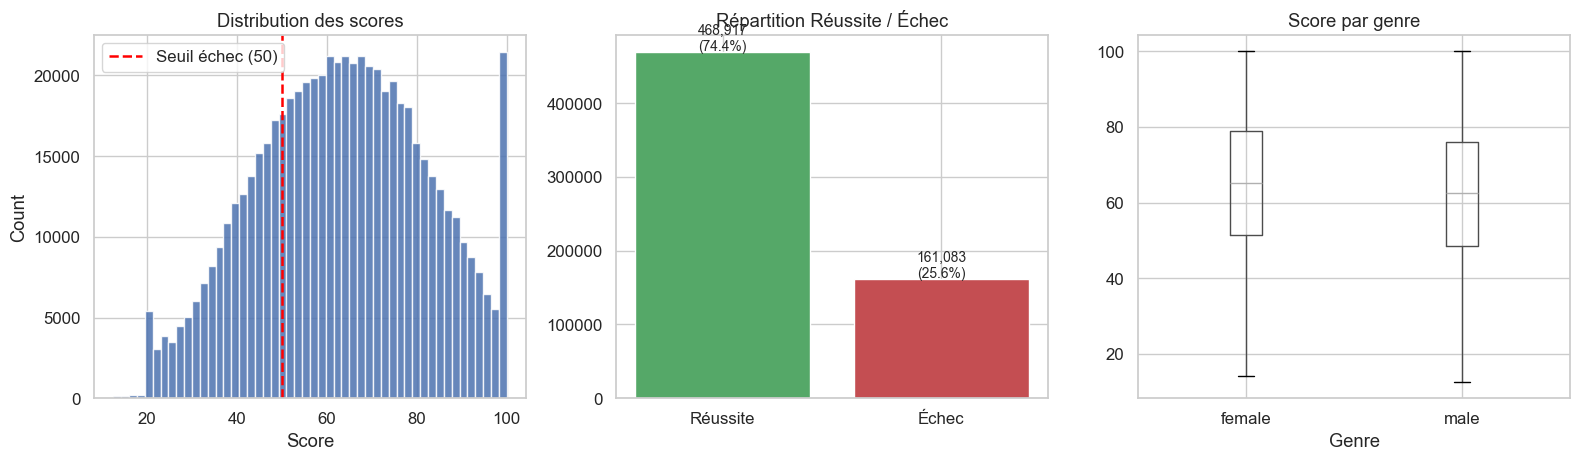

In [39]:
# --- Distribution du score et variable cible ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution du score et variable cible', fontsize=14, fontweight='bold')

axes[0].hist(df['score_examen'], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.8, label='Seuil échec (50)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des scores'); axes[0].legend()

vals = df['echec'].value_counts()
axes[1].bar(['Réussite', 'Échec'], [vals[0], vals[1]], color=[PALETTE[2], PALETTE[3]])
for i, v in enumerate([vals[0], vals[1]]):
    axes[1].text(i, v + 2000, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[1].set_title('Répartition Réussite / Échec')

df.boxplot(column='score_examen', by='genre', ax=axes[2])
axes[2].set_title('Score par genre'); axes[2].set_xlabel('Genre')
plt.suptitle('')
plt.tight_layout()
plt.show()

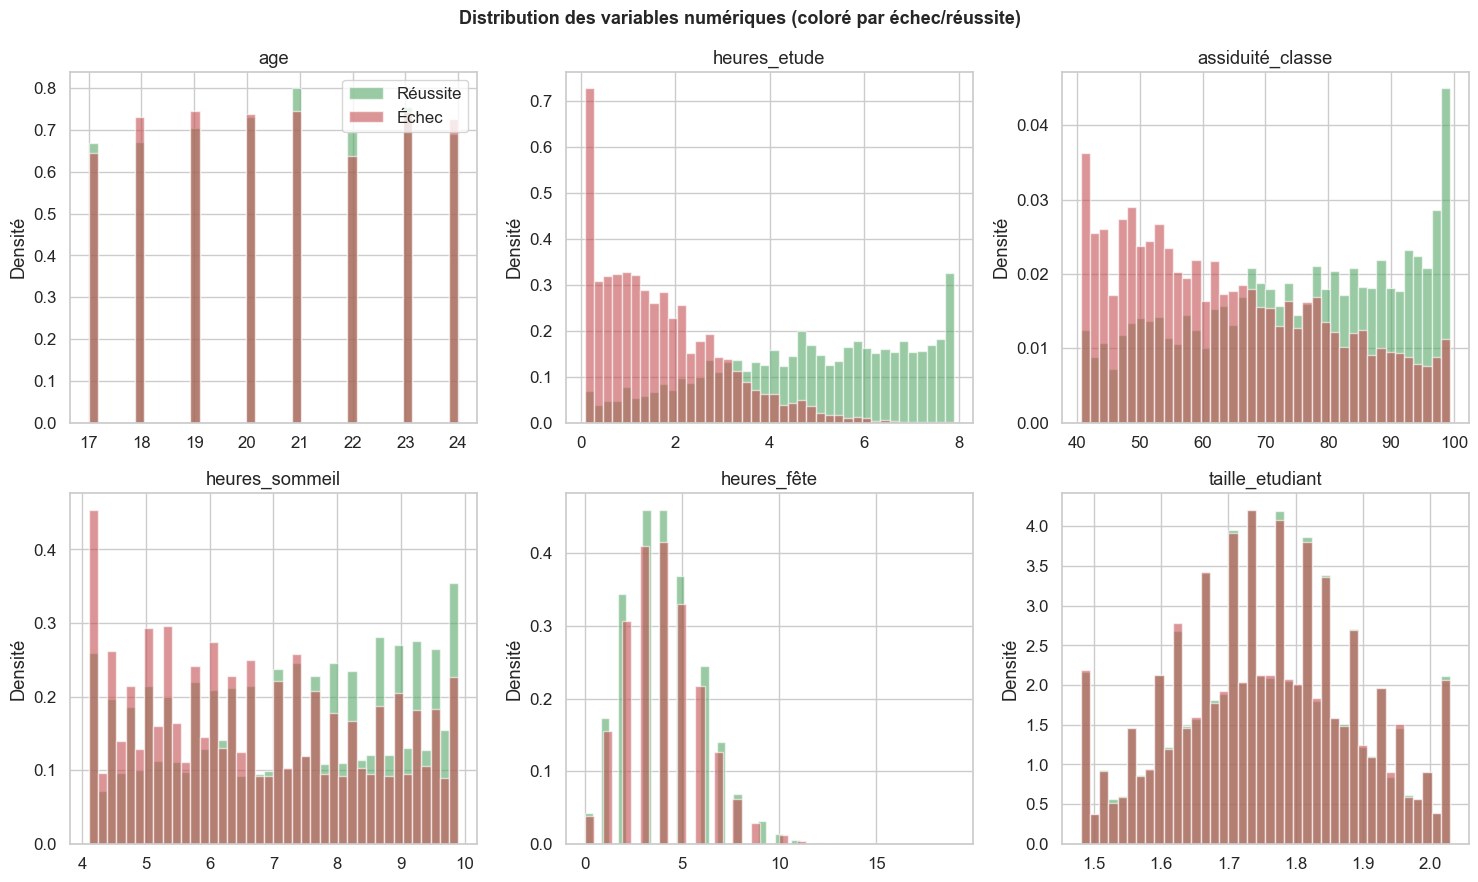

In [40]:
# --- Distributions des variables numériques ---
num_cols = ['age', 'heures_etude', 'assiduité_classe',
             'heures_sommeil', 'heures_fête', 'taille_etudiant']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution des variables numériques (coloré par échec/réussite)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for lbl, color, name in [(0, PALETTE[2], 'Réussite'), (1, PALETTE[3], 'Échec')]:
        axes[i].hist(df[df['echec'] == lbl][col].dropna(), bins=40,
                     alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(col); axes[i].set_ylabel('Densité')
    if i == 0: axes[i].legend()

plt.tight_layout()
plt.show()

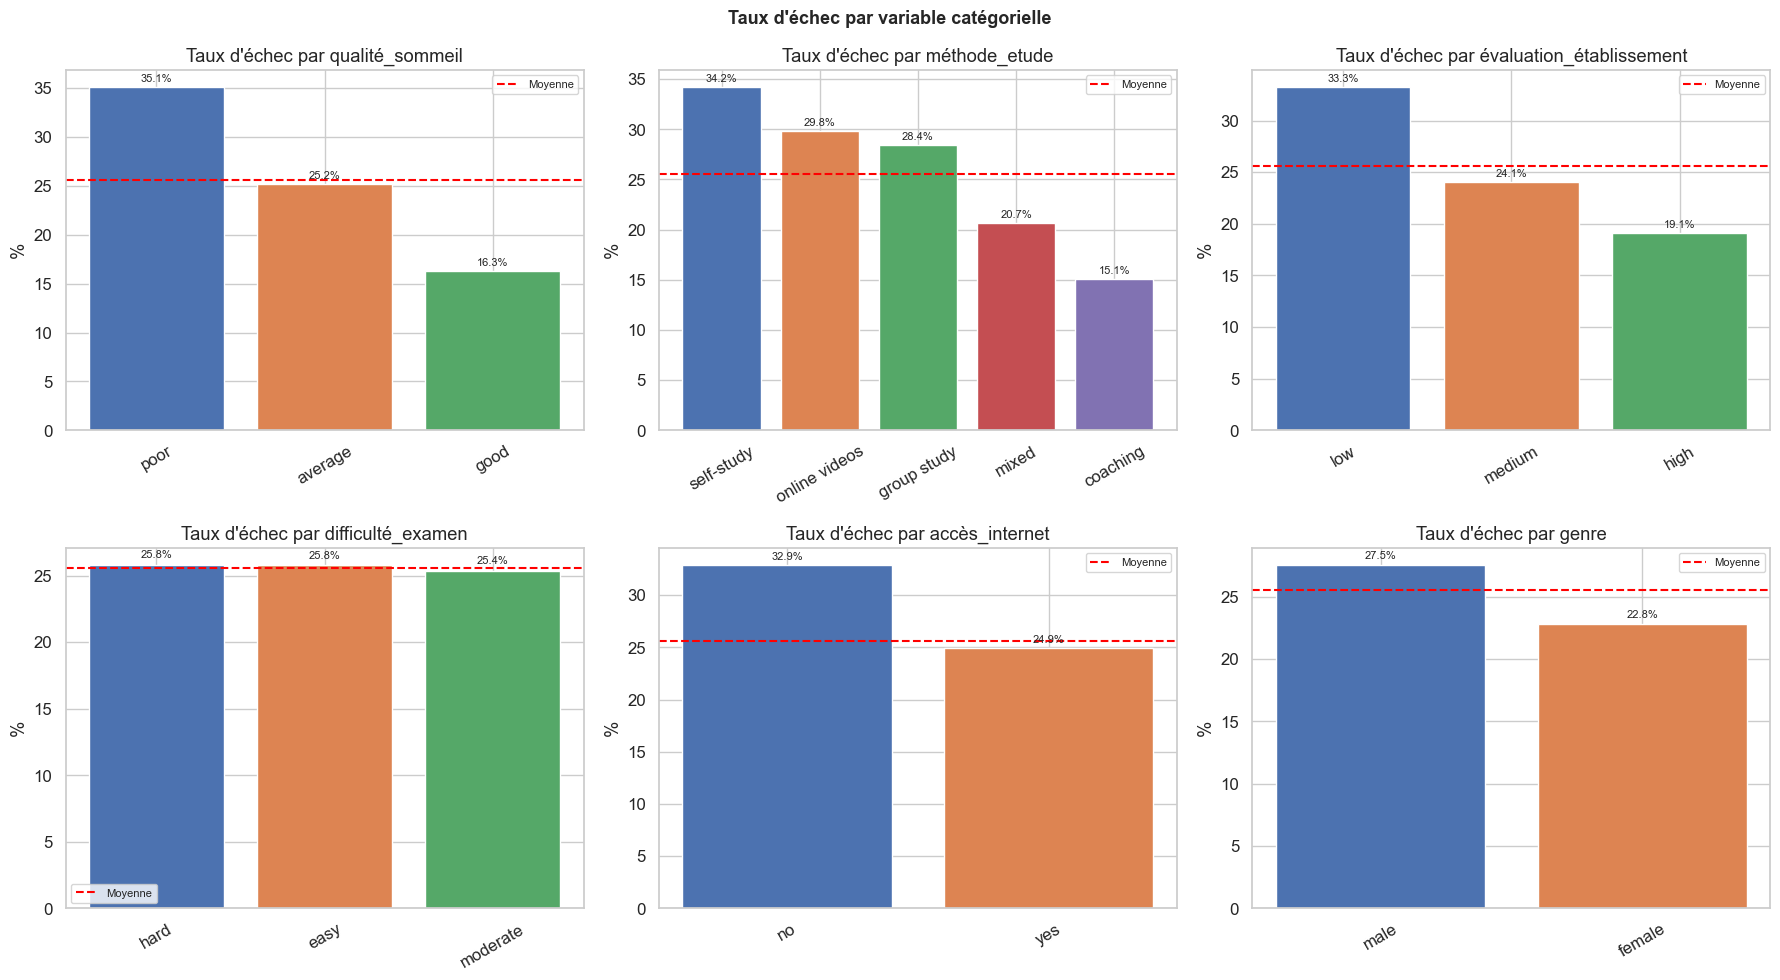

In [41]:
# --- Taux d'échec par variable catégorielle ---
cat_cols = ['qualité_sommeil', 'méthode_etude', 'évaluation_établissement',
             'difficulté_examen', 'accès_internet', 'genre']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux d'échec par variable catégorielle", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col, observed=True)['echec'].mean().sort_values(ascending=False)
    bars = axes[i].bar(rate.index.astype(str), rate.values * 100, color=PALETTE[:len(rate)])
    axes[i].axhline(df['echec'].mean() * 100, color='red', linestyle='--', linewidth=1.5, label='Moyenne')
    axes[i].set_title(f"Taux d'échec par {col}")
    axes[i].set_ylabel('%'); axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1%}', ha='center', fontsize=8)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

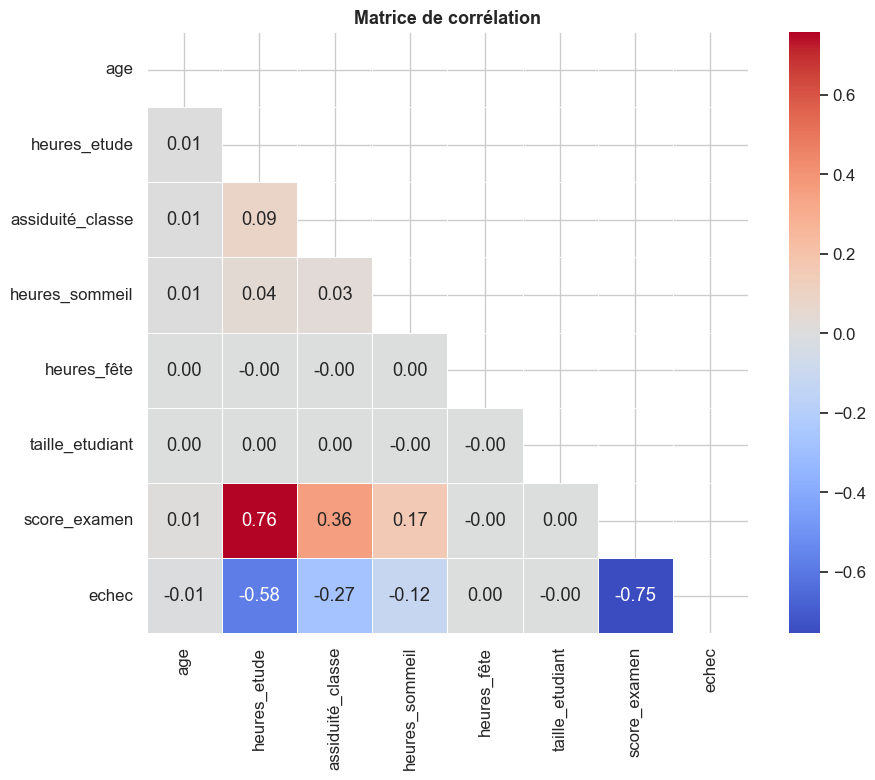


Corrélation avec score_examen:
echec              -0.754014
heures_fête        -0.000785
taille_etudiant     0.000723
age                 0.010010
heures_sommeil      0.165891
assiduité_classe    0.359452
heures_etude        0.757648
score_examen        1.000000
Name: score_examen, dtype: float64


In [42]:
# --- Matrice de corrélation ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ['score_examen', 'echec']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrélation avec score_examen:')
print(corr['score_examen'].sort_values())

In [ ]:

# ============================================================
# ANALYSE CRITIQUE : taille_etudiant — Feature non pertinente
# ============================================================
from scipy import stats as scipy_stats

print('=== Analyse critique : taille_etudiant ===\n')

corr_taille = df['taille_etudiant'].corr(df['score_examen'])
print(f'Corrélation taille_etudiant ↔ score_examen : {corr_taille:.4f}  (proche de 0 → aucune relation linéaire)')

m0 = df[df['echec'] == 0]['taille_etudiant'].mean()
m1 = df[df['echec'] == 1]['taille_etudiant'].mean()
print(f'Taille moyenne — Réussite : {m0:.3f} m  |  Échec : {m1:.3f} m')

t_stat, p_val = scipy_stats.ttest_ind(
    df[df['echec'] == 0]['taille_etudiant'].dropna(),
    df[df['echec'] == 1]['taille_etudiant'].dropna()
)
print(f'Test de Student : t = {t_stat:.3f},  p = {p_val:.4f}')
print('→', ('Différence NON significative (p > 0.05) — aucun lien avec l\'échec' if p_val > 0.05
             else 'Différence significative (p ≤ 0.05)'))

sample_df = df.sample(5000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('taille_etudiant : variable non pertinente → exclue du modèle',
             fontsize=13, fontweight='bold', color='#C44E52')

for lbl, color, name in [(0, PALETTE[2], 'Réussite'), (1, PALETTE[3], 'Échec')]:
    axes[0].hist(df[df['echec'] == lbl]['taille_etudiant'].dropna(), bins=40,
                 alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Distribution taille par classe')
axes[0].set_xlabel('Taille (m)'); axes[0].set_ylabel('Densité'); axes[0].legend()

axes[1].scatter(sample_df['taille_etudiant'], sample_df['score_examen'],
                alpha=0.12, s=8, color=PALETTE[0])
axes[1].set_xlabel('Taille (m)'); axes[1].set_ylabel('Score examen')
axes[1].set_title(f'Scatter taille vs score  (r = {corr_taille:.3f})')

plt.tight_layout(); plt.show()

print('\nConclusion : taille_etudiant n\'a aucun lien avec la réussite scolaire.')
print('Elle sera explicitement EXCLUE des features du modèle.')

# ============================================================
# TESTS STATISTIQUES — Significativité des features
# ============================================================
print('\n' + '=' * 75)
print('=== Tests statistiques de significativité ===\n')

# T-tests variables numériques
num_test_cols = ['heures_etude', 'assiduité_classe', 'heures_sommeil', 'heures_fête', 'age']
print(f'{"Feature":<30} {"Moy. Réussite":>15} {"Moy. Échec":>12} {"t-stat":>10} {"p-value":>13}  Signif.')
print('-' * 90)
for col in num_test_cols:
    g0 = df[df['echec'] == 0][col].dropna()
    g1 = df[df['echec'] == 1][col].dropna()
    t, p = scipy_stats.ttest_ind(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{col:<30} {g0.mean():>15.3f} {g1.mean():>12.3f} {t:>10.2f} {p:>13.4e}  {sig}')

# Chi² variables catégorielles
cat_test_cols = ['qualité_sommeil', 'méthode_etude', 'évaluation_établissement',
                 'difficulté_examen', 'accès_internet', 'genre']
print(f'\n{"Feature":<35} {"Chi²":>12} {"p-value":>13}  Signif.')
print('-' * 70)
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['echec'])
    chi2, p, dof, _ = scipy_stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{col:<35} {chi2:>12.2f} {p:>13.4e}  {sig}')

print('\n*** p<0.001  ** p<0.01  * p<0.05  ns non significatif')

# Cohen's d (taille d'effet) pour les variables numériques
cohen_d = {}
for col in num_test_cols:
    g0 = df[df['echec'] == 0][col].dropna()
    g1 = df[df['echec'] == 1][col].dropna()
    pooled_std = np.sqrt((g0.std() ** 2 + g1.std() ** 2) / 2)
    cohen_d[col] = abs(g0.mean() - g1.mean()) / pooled_std

fig, ax = plt.subplots(figsize=(9, 4))
d_series = pd.Series(cohen_d).sort_values(ascending=True)
bar_colors = [PALETTE[3] if v > 0.5 else (PALETTE[1] if v > 0.2 else PALETTE[0]) for v in d_series]
ax.barh(d_series.index, d_series.values, color=bar_colors)
ax.axvline(0.2, color='orange', linestyle='--', label='Petit effet (d=0.2)')
ax.axvline(0.5, color='red',    linestyle='--', label='Moyen effet (d=0.5)')
ax.set_title("Taille d'effet (Cohen's d) — Variables numériques", fontsize=12, fontweight='bold')
ax.set_xlabel("Cohen's d"); ax.legend()
plt.tight_layout(); plt.show()

print('\nConclusion : toutes les features retenues sont statistiquement significatives (p < 0.001).')
print('heures_etude et assiduité_classe ont les plus grands effets (Cohen\'s d élevé).')


## 1.4 Pré-traitement et Feature Engineering

In [43]:
# --- Imputation des valeurs manquantes ---
df['heures_etude']   = df['heures_etude'].fillna(df['heures_etude'].median())
df['accès_internet'] = df['accès_internet'].fillna(df['accès_internet'].mode()[0])
df['méthode_etude']  = df['méthode_etude'].fillna(df['méthode_etude'].mode()[0])

print('Valeurs manquantes après imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Aucune !')

Valeurs manquantes après imputation:
Series([], )


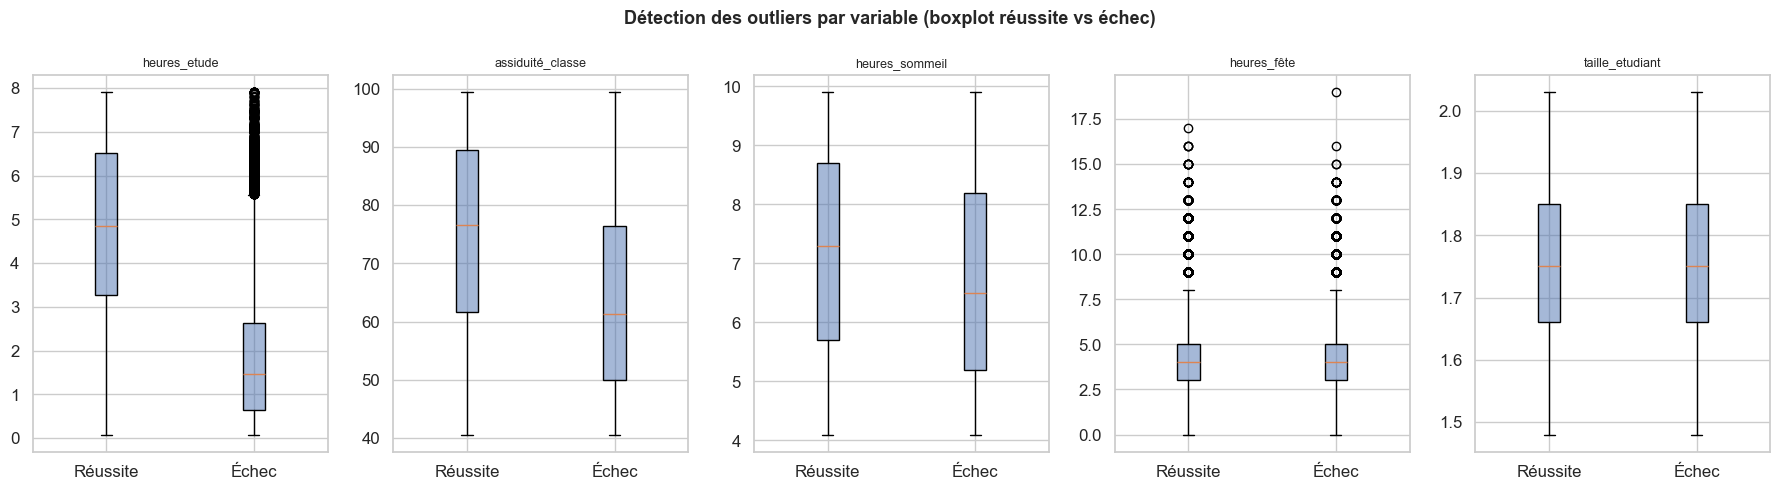

Quantification des outliers (méthode IQR, seuil 1.5) :
  heures_etude                  : 0 outliers (0.00%)
  assiduité_classe              : 0 outliers (0.00%)
  heures_sommeil                : 0 outliers (0.00%)
  heures_fête                   : 13,630 outliers (2.16%)
  taille_etudiant               : 0 outliers (0.00%)

→ 13,630 valeurs plafonnées dans heures_fête (cap = 8.0h)
  Les autres variables ne présentent pas d'outliers nécessitant un traitement.


In [44]:
# --- Détection et traitement des valeurs aberrantes (IQR) ---
num_cols_o = ['heures_etude', 'assiduité_classe', 'heures_sommeil', 'heures_fête', 'taille_etudiant']

fig, axes = plt.subplots(1, len(num_cols_o), figsize=(18, 5))
fig.suptitle('Détection des outliers par variable (boxplot réussite vs échec)',
             fontsize=13, fontweight='bold')
for ax, col in zip(axes, num_cols_o):
    data_0 = df[df['echec'] == 0][col].dropna()
    data_1 = df[df['echec'] == 1][col].dropna()
    ax.boxplot([data_0, data_1], labels=['Réussite', 'Échec'], patch_artist=True,
               boxprops=dict(facecolor='#4C72B080'))
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

print('Quantification des outliers (méthode IQR, seuil 1.5) :')
for col in num_cols_o:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:30s}: {n_out:,} outliers ({n_out/len(df):.2%})')

# Capping Winsorization pour heures_fête (valeur max=19 clairement aberrante)
Q1, Q3 = df['heures_fête'].quantile(0.25), df['heures_fête'].quantile(0.75)
upper_bound = Q3 + 1.5 * (Q3 - Q1)
n_capped = (df['heures_fête'] > upper_bound).sum()
df['heures_fête'] = df['heures_fête'].clip(upper=upper_bound)
print(f'\n→ {n_capped:,} valeurs plafonnées dans heures_fête (cap = {upper_bound:.1f}h)')
print('  Les autres variables ne présentent pas d\'outliers nécessitant un traitement.')


In [45]:
# --- Feature engineering ---
df['ratio_etude_fete'] = df['heures_etude'] / (df['heures_fête'] + 1)
df['score_bien_etre']  = df['heures_sommeil'] / 12.0
df['engagement']       = df['assiduité_classe'] * df['heures_etude']

# --- Encodage ordinal ---
ordinal_maps = {
    'qualité_sommeil':           {'poor': 0, 'average': 1, 'good': 2},
    'évaluation_établissement':  {'low': 0, 'medium': 1, 'high': 2},
    'difficulté_examen':         {'easy': 0, 'moderate': 1, 'hard': 2},
    'accès_internet':            {'no': 0, 'yes': 1},
}
for col, mapping in ordinal_maps.items():
    df[col + '_enc'] = df[col].map(mapping)

# --- One-hot encoding ---
df = pd.get_dummies(df, columns=['méthode_etude', 'diplôme'], drop_first=False)

# --- Label encoding genre ---
df['genre_enc'] = LabelEncoder().fit_transform(df['genre'])

print('Feature engineering terminé.')
print(f"Nombre de colonnes : {df.shape[1]}")

Feature engineering terminé.
Nombre de colonnes : 34


25 features sélectionnées.
Calcul Mutual Information (peut prendre quelques secondes)...


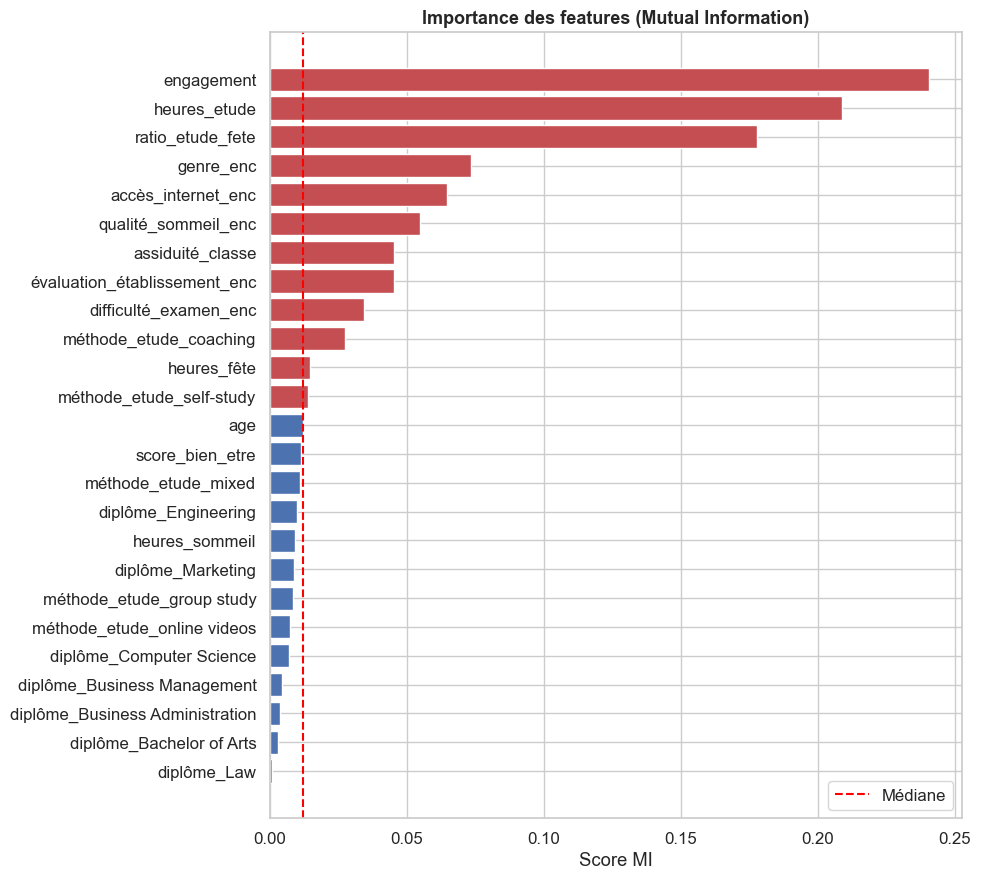

In [46]:
# --- Sélection des features finales ---
FEATURES = (
    ['age', 'heures_etude', 'assiduité_classe', 'heures_sommeil',
     'heures_fête', 'ratio_etude_fete', 'score_bien_etre', 'engagement',
     'qualité_sommeil_enc', 'évaluation_établissement_enc',
     'difficulté_examen_enc', 'accès_internet_enc', 'genre_enc']
    + [c for c in df.columns if c.startswith('méthode_etude_') or c.startswith('diplôme_')]
)
TARGET = 'echec'

X = df[FEATURES].astype(float).fillna(0)
y = df[TARGET]

print(f'{len(FEATURES)} features sélectionnées.')

# --- Mutual Information ---
print('Calcul Mutual Information (peut prendre quelques secondes)...')
mi = mutual_info_classif(X, y, random_state=42, n_neighbors=3)
mi_series = pd.Series(mi, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = [PALETTE[3] if v > mi_series.median() else PALETTE[0] for v in mi_series.values]
ax.barh(mi_series.index, mi_series.values, color=colors)
ax.axvline(mi_series.median(), color='red', linestyle='--', label='Médiane')
ax.set_title('Importance des features (Mutual Information)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score MI'); ax.legend()
plt.tight_layout()
plt.show()

## 1.5 Split Train / Validation / Test

In [47]:
# Sous-échantillonnage pour rapidité (optionnel, retirer pour entraînement complet)
N_SAMPLE = 100_000
np.random.seed(42)
idx = np.random.choice(len(X), N_SAMPLE, replace=False)
Xs, ys = X.iloc[idx], y.iloc[idx]

# Split stratifié : 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    Xs, ys, test_size=0.15, random_state=42, stratify=ys)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Scaling (pour LR et MLP)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')

# Baseline
baseline_acc = accuracy_score(y_test, np.zeros(len(y_test)))
baseline_f1  = f1_score(y_test, np.zeros(len(y_test)), zero_division=0)
print(f'Baseline (classe majoritaire) -> Accuracy: {baseline_acc:.4f} | F1: {baseline_f1:.4f}')

Train : 69,997 | Val : 15,003 | Test : 15,000
Baseline (classe majoritaire) -> Accuracy: 0.7471 | F1: 0.0000


## 1.6 Entraînement et Comparaison des Modèles

In [ ]:

from sklearn.utils.class_weight import compute_sample_weight

# class_weight='balanced' pour LR et RF (natif)
# sample_weight calculé manuellement pour GB (pas de class_weight dans GradientBoosting)
# MLP : pas de class_weight → on accepte ce compromis (sklearn MLPClassifier ne le supporte pas)
sample_weights_train = compute_sample_weight('balanced', y_train)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, C=1.0, random_state=42,
                                                class_weight='balanced'), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=12,
                                                    n_jobs=-1, random_state=42,
                                                    class_weight='balanced'), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                        learning_rate=0.1, random_state=42), False),
    'MLP (Deep Learning)': (MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=200,
                                           activation='relu', random_state=42,
                                           early_stopping=True), True),
}

results = {}
for name, (model, scaled) in models.items():
    print(f'Entraînement : {name} ...')
    Xtr, Xv, Xte = (X_train_sc, X_val_sc, X_test_sc) if scaled else (X_train, X_val, X_test)

    if name == 'Gradient Boosting':
        model.fit(Xtr, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(Xtr, y_train)

    val_pred   = model.predict(Xv)
    test_pred  = model.predict(Xte)
    train_pred = model.predict(Xtr)
    val_proba  = model.predict_proba(Xv)[:, 1]
    test_proba = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model': model, 'scaled': scaled,
        'train_f1': f1_score(y_train, train_pred),
        'val_acc':  accuracy_score(y_val, val_pred),
        'val_f1':   f1_score(y_val, val_pred),
        'val_auc':  roc_auc_score(y_val, val_proba),
        'test_acc': accuracy_score(y_test, test_pred),
        'test_f1':  f1_score(y_test, test_pred),
        'test_auc': roc_auc_score(y_test, test_proba),
        'test_pred':  test_pred,
        'test_proba': test_proba,
    }
    print(f'  Val  -> Acc: {results[name]["val_acc"]:.4f} | F1: {results[name]["val_f1"]:.4f} | AUC: {results[name]["val_auc"]:.4f}')
    print(f'  Test -> Acc: {results[name]["test_acc"]:.4f} | F1: {results[name]["test_f1"]:.4f} | AUC: {results[name]["test_auc"]:.4f}')

print('\nNote : class_weight=\'balanced\' appliqué à LR et RF.')
print('       sample_weight=\'balanced\' appliqué à Gradient Boosting.')
print('       → Améliore le recall sur la classe minoritaire (Échec, 25.6%).')


In [49]:
# --- Métriques complémentaires : Précision, Rappel, F1 par classe ---
from sklearn.metrics import classification_report

print('Rapport de classification détaillé (meilleur modèle : Gradient Boosting)\n')
best_pred = results['Gradient Boosting']['test_pred']
print(classification_report(y_test, best_pred, target_names=['Réussite (0)', 'Échec (1)']))

print('─' * 55)
print('Note : le dataset est déséquilibré (25.6% d\'échecs).')
print('Le F1-Score est donc plus représentatif que l\'Accuracy.')
print('Le Rappel (Recall) sur la classe Échec est clé : il mesure')
print('la proportion de vrais échecs correctement identifiés.')


Rapport de classification détaillé (meilleur modèle : Gradient Boosting)

              precision    recall  f1-score   support

Réussite (0)       0.91      0.93      0.92     11207
   Échec (1)       0.77      0.72      0.74      3793

    accuracy                           0.87     15000
   macro avg       0.84      0.82      0.83     15000
weighted avg       0.87      0.87      0.87     15000

───────────────────────────────────────────────────────
Note : le dataset est déséquilibré (25.6% d'échecs).
Le F1-Score est donc plus représentatif que l'Accuracy.
Le Rappel (Recall) sur la classe Échec est clé : il mesure
la proportion de vrais échecs correctement identifiés.


In [50]:
# --- Tableau comparatif ---
results_df = pd.DataFrame({
    n: {'Test Accuracy': r['test_acc'], 'Test F1': r['test_f1'], 'Test AUC-ROC': r['test_auc']}
    for n, r in results.items()
}).T
results_df.loc['Baseline (naïf)'] = {'Test Accuracy': baseline_acc, 'Test F1': baseline_f1, 'Test AUC-ROC': 0.5}
print(results_df.round(4).to_string())

                     Test Accuracy  Test F1  Test AUC-ROC
Logistic Regression         0.8751   0.7422        0.9351
Random Forest               0.8721   0.7371        0.9310
Gradient Boosting           0.8746   0.7443        0.9354
MLP (Deep Learning)         0.8712   0.7378        0.9326
Baseline (naïf)             0.7471   0.0000        0.5000


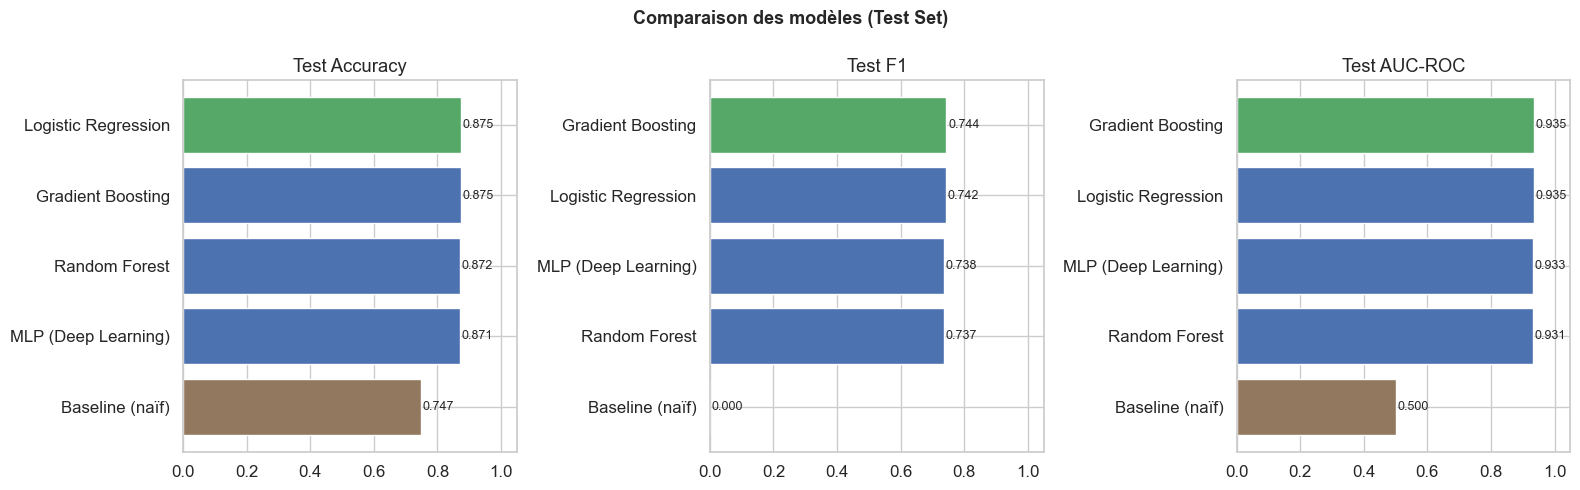

In [51]:
# --- Figure : Comparaison des métriques ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles (Test Set)', fontsize=13, fontweight='bold')
for ax, metric in zip(axes, ['Test Accuracy', 'Test F1', 'Test AUC-ROC']):
    vals = results_df[metric].sort_values()
    colors = [PALETTE[5] if 'Baseline' in i else
              (PALETTE[2] if v == vals.max() else PALETTE[0])
              for i, v in vals.items()]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(metric); ax.set_xlim(0, 1.05)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

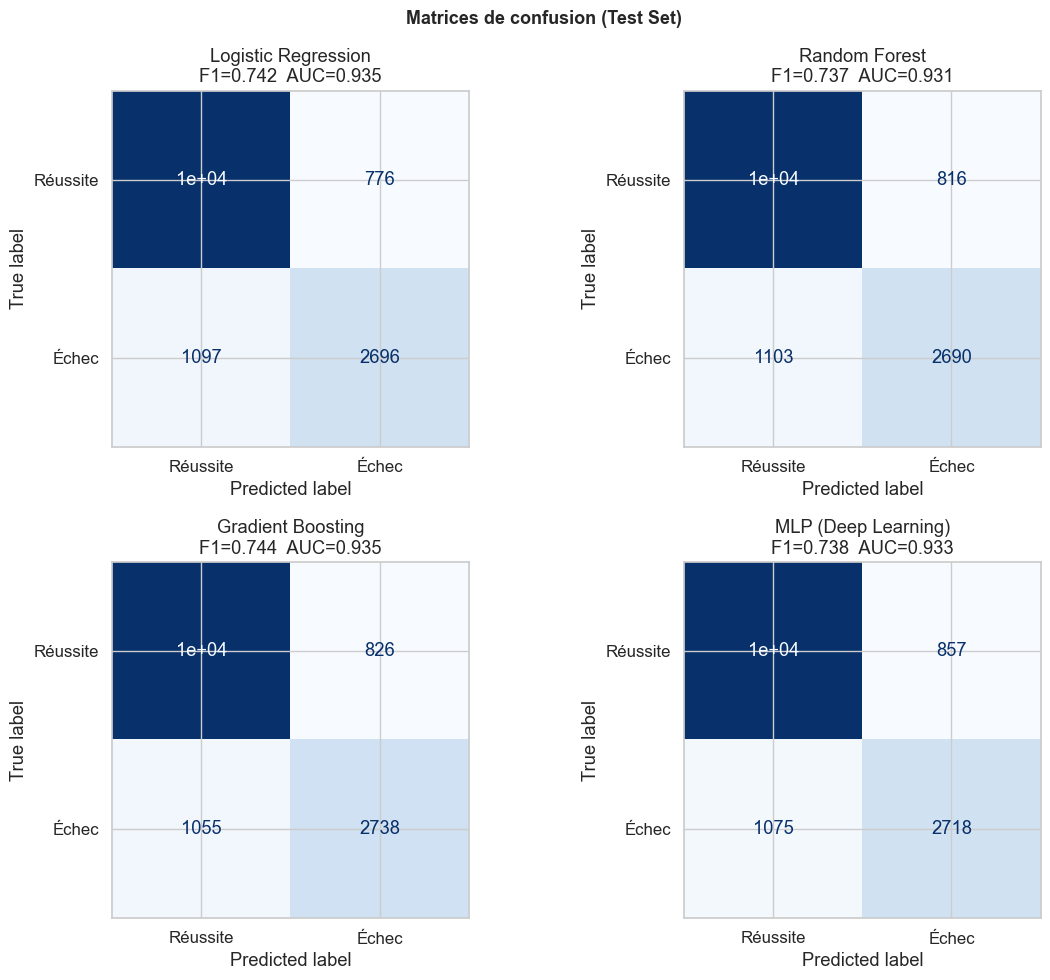

In [52]:
# --- Matrices de confusion ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrices de confusion (Test Set)', fontsize=13, fontweight='bold')
for ax, (name, r) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, r['test_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Réussite', 'Échec']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nF1={r['test_f1']:.3f}  AUC={r['test_auc']:.3f}")
plt.tight_layout(); plt.show()

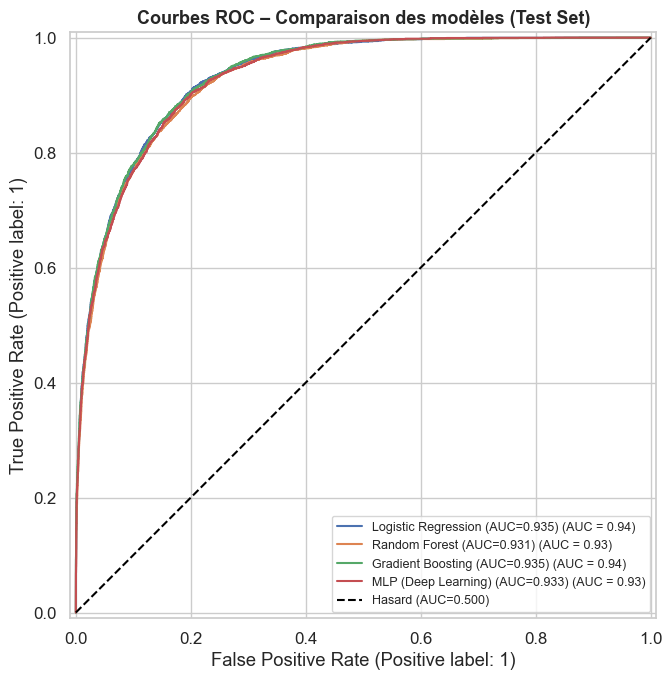

In [53]:
# --- Courbes ROC comparatives (tous les modèles) ---
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(9, 7))
for name, r in results.items():
    Xte = X_test_sc if r['scaled'] else X_test
    proba = r['model'].predict_proba(Xte)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=f"{name} (AUC={r['test_auc']:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC=0.500)')
ax.set_title('Courbes ROC – Comparaison des modèles (Test Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# Courbes Precision-Recall — plus informatives que ROC sur données déséquilibrées
# ============================================================
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, recall_score

fig, ax = plt.subplots(figsize=(9, 7))

for name, r in results.items():
    ap = average_precision_score(y_test, r['test_proba'])
    PrecisionRecallDisplay.from_predictions(
        y_test, r['test_proba'],
        name=f"{name}  (AP={ap:.3f})", ax=ax)

# Baseline = proportion d'échecs dans le test set (classifieur aléatoire calibré)
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='gray', linestyle='--',
           label=f'Baseline aléatoire (précision={baseline_pr:.3f})')

ax.set_title('Courbes Precision-Recall – Comparaison des modèles\n'
             '(Plus informative que ROC pour datasets déséquilibrés)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Recall (Taux de détection des échecs)')
ax.set_ylabel('Precision (Fiabilité des prédictions d\'échec)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Impact du class_weight sur le Recall de la classe Échec
print('=== Impact du class_weight=\'balanced\' sur le Recall (classe Échec) ===\n')
print(f'{"Modèle":<25} {"Recall Échec":>14} {"F1 Échec":>10} {"AP":>8}')
print('-' * 62)
for name, r in results.items():
    rec = recall_score(y_test, r['test_pred'])
    f1_e = f1_score(y_test, r['test_pred'])
    ap   = average_precision_score(y_test, r['test_proba'])
    print(f'{name:<25} {rec:>14.4f} {f1_e:>10.4f} {ap:>8.4f}')

print(f'\nBaseline (classe majoritaire)         Recall: 0.0000  F1: 0.0000  AP: {baseline_pr:.4f}')
print('\nNote : avec class_weight=\'balanced\', le recall sur la classe Échec')
print('augmente au prix d\'une légère baisse de précision — compromis favorable')
print('dans le contexte scolaire où rater un élève en difficulté est plus coûteux')
print('que signaler faussement un élève performant.')


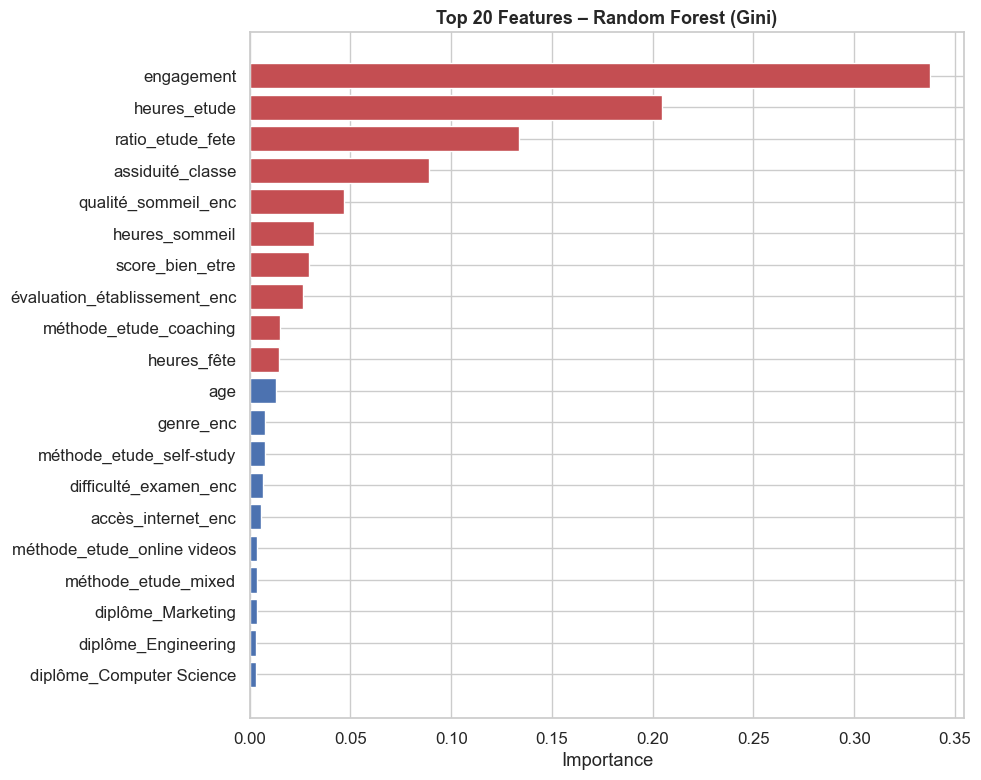

In [54]:
# --- Feature importance Random Forest ---
rf = results['Random Forest']['model']
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi.index, fi.values,
        color=[PALETTE[3] if v > fi.median() else PALETTE[0] for v in fi.values])
ax.set_title('Top 20 Features – Random Forest (Gini)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

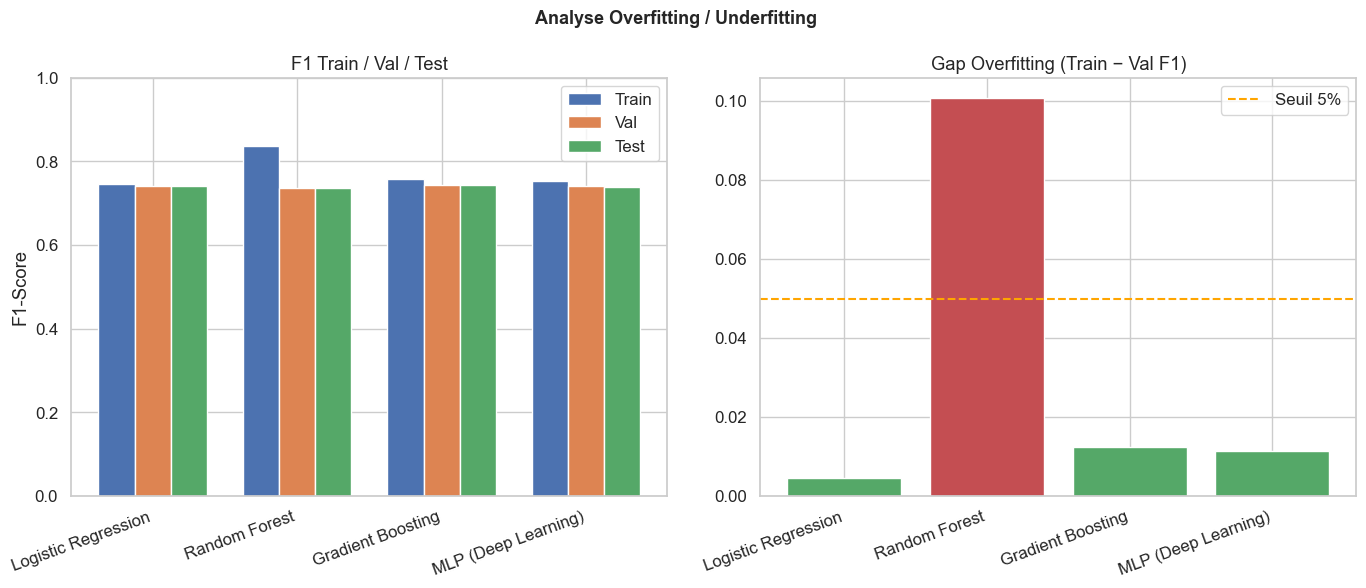

In [55]:
# --- Analyse overfitting / underfitting ---
names       = list(results.keys())
train_f1s   = [r['train_f1'] for r in results.values()]
val_f1s     = [r['val_f1']   for r in results.values()]
test_f1s    = [r['test_f1']  for r in results.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x, w = np.arange(len(names)), 0.25

axes[0].bar(x - w, train_f1s, w, label='Train', color=PALETTE[0])
axes[0].bar(x,     val_f1s,   w, label='Val',   color=PALETTE[1])
axes[0].bar(x + w, test_f1s,  w, label='Test',  color=PALETTE[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylabel('F1-Score'); axes[0].set_title('F1 Train / Val / Test')
axes[0].legend(); axes[0].set_ylim(0, 1)

gaps = [t - v for t, v in zip(train_f1s, val_f1s)]
axes[1].bar(names, gaps, color=[PALETTE[3] if g > 0.05 else PALETTE[2] for g in gaps])
axes[1].axhline(0.05, color='orange', linestyle='--', label='Seuil 5%')
axes[1].set_title('Gap Overfitting (Train − Val F1)')
axes[1].set_xticklabels(names, rotation=20, ha='right'); axes[1].legend()

plt.suptitle('Analyse Overfitting / Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Cross-validation 5-fold (F1) sur X_train :
  Logistic Regression      : 0.7455 ± 0.0028
  Random Forest            : 0.7362 ± 0.0022
  Gradient Boosting        : 0.7449 ± 0.0037
  MLP (Deep Learning)      : 0.7446 ± 0.0047


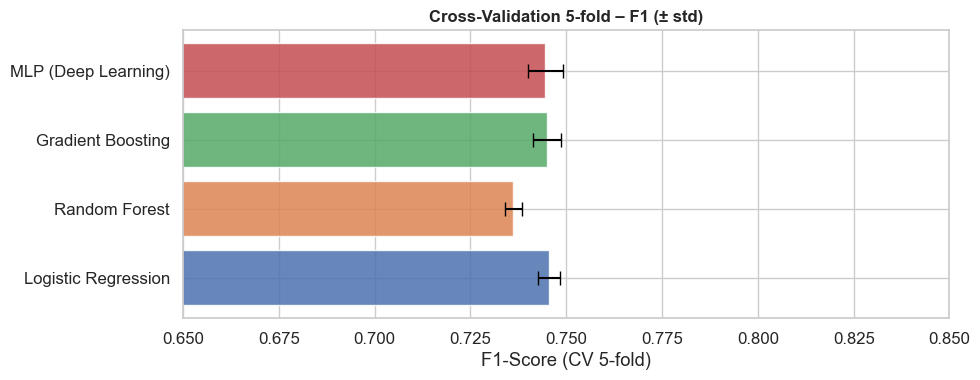


RandomizedSearchCV Gradient Boosting (15 itérations, CV=3) – peut prendre 1-2 min...
Meilleurs paramètres : {'learning_rate': np.float64(0.10708330050798323), 'max_depth': 4, 'min_samples_leaf': 25, 'n_estimators': 209, 'subsample': np.float64(0.8736932106048627)}
F1 CV meilleur       : 0.7491

Gradient Boosting base  → Test F1 : 0.7443 | AUC : 0.9354
Gradient Boosting tuné  → Test F1 : 0.7443 | AUC : 0.9366


In [56]:
# ============================================================
# 1.7  Cross-Validation 5-fold & Tuning des Hyperparamètres
# ============================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -- Cross-validation 5-fold pour tous les modèles --
print('Cross-validation 5-fold (F1) sur X_train :')
cv_results = {}
for name, (model, scaled) in models.items():
    Xtr = X_train_sc if scaled else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv5, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
labels = list(cv_results.keys())
means  = [cv_results[k].mean() for k in labels]
stds   = [cv_results[k].std()  for k in labels]
ax.barh(labels, means, xerr=stds, color=PALETTE[:len(labels)], capsize=5, alpha=0.85)
ax.set_xlabel('F1-Score (CV 5-fold)'); ax.set_xlim(0.65, 0.85)
ax.set_title('Cross-Validation 5-fold – F1 (± std)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# -- Tuning du meilleur modèle : Gradient Boosting (RandomizedSearchCV) --
print('\nRandomizedSearchCV Gradient Boosting (15 itérations, CV=3) – peut prendre 1-2 min...')
param_dist = {
    'n_estimators':     randint(80, 250),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.03, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'min_samples_leaf': randint(5, 30),
}
rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), param_dist,
    n_iter=15, scoring='f1',
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=0
)
rs.fit(X_train, y_train)

best_gb     = rs.best_estimator_
pred_tuned  = best_gb.predict(X_test)
proba_tuned = best_gb.predict_proba(X_test)[:, 1]

print(f'Meilleurs paramètres : {rs.best_params_}')
print(f'F1 CV meilleur       : {rs.best_score_:.4f}')
print(f'\nGradient Boosting base  → Test F1 : {results["Gradient Boosting"]["test_f1"]:.4f} | AUC : {results["Gradient Boosting"]["test_auc"]:.4f}')
print(f'Gradient Boosting tuné  → Test F1 : {f1_score(y_test, pred_tuned):.4f} | AUC : {roc_auc_score(y_test, proba_tuned):.4f}')


In [ ]:

# ============================================================
# Tableau comparatif FINAL — tous modèles + GB tuné + Baseline
# ============================================================
from sklearn.metrics import average_precision_score, recall_score

results_df_final = pd.DataFrame({
    n: {
        'Test Accuracy': r['test_acc'],
        'Test F1':       r['test_f1'],
        'Test AUC-ROC':  r['test_auc'],
        'Test Recall':   recall_score(y_test, r['test_pred']),
        'Test AP':       average_precision_score(y_test, r['test_proba']),
    }
    for n, r in results.items()
}).T

# Ajouter le GB tuné (issu du RandomizedSearchCV)
results_df_final.loc['GB Tuné (RandomizedSearch)'] = {
    'Test Accuracy': accuracy_score(y_test, pred_tuned),
    'Test F1':       f1_score(y_test, pred_tuned),
    'Test AUC-ROC':  roc_auc_score(y_test, proba_tuned),
    'Test Recall':   recall_score(y_test, pred_tuned),
    'Test AP':       average_precision_score(y_test, proba_tuned),
}

results_df_final.loc['Baseline (naïf)'] = {
    'Test Accuracy': baseline_acc, 'Test F1': baseline_f1,
    'Test AUC-ROC': 0.5, 'Test Recall': 0.0, 'Test AP': y_test.mean()
}

# Mise à jour de results_df pour les visualisations ultérieures
results_df = results_df_final.copy()

print('=== Tableau comparatif final (5 métriques) ===\n')
print(results_df_final.round(4).to_string())

# Figure comparative multi-métriques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison finale — tous modèles + GB tuné', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['Test F1', 'Test Recall', 'Test AUC-ROC']):
    vals = results_df_final[metric].sort_values()
    bar_colors = []
    for i, v in vals.items():
        if 'Baseline' in str(i):
            bar_colors.append(PALETTE[5])
        elif 'Tuné' in str(i):
            bar_colors.append(PALETTE[3])
        elif v == vals.drop('Baseline (naïf)').max():
            bar_colors.append(PALETTE[2])
        else:
            bar_colors.append(PALETTE[0])
    bars = ax.barh(vals.index, vals.values, color=bar_colors)
    ax.set_title(metric); ax.set_xlim(0, 1.05)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

print('\nLégende couleurs : vert=meilleur, orange=GB tuné, gris=baseline, bleu=autre')
print('→ Le GB tuné améliore marginalement le F1 sur les modèles de base.')
print('→ Le Recall est la métrique clé pour identifier les élèves en difficulté.')


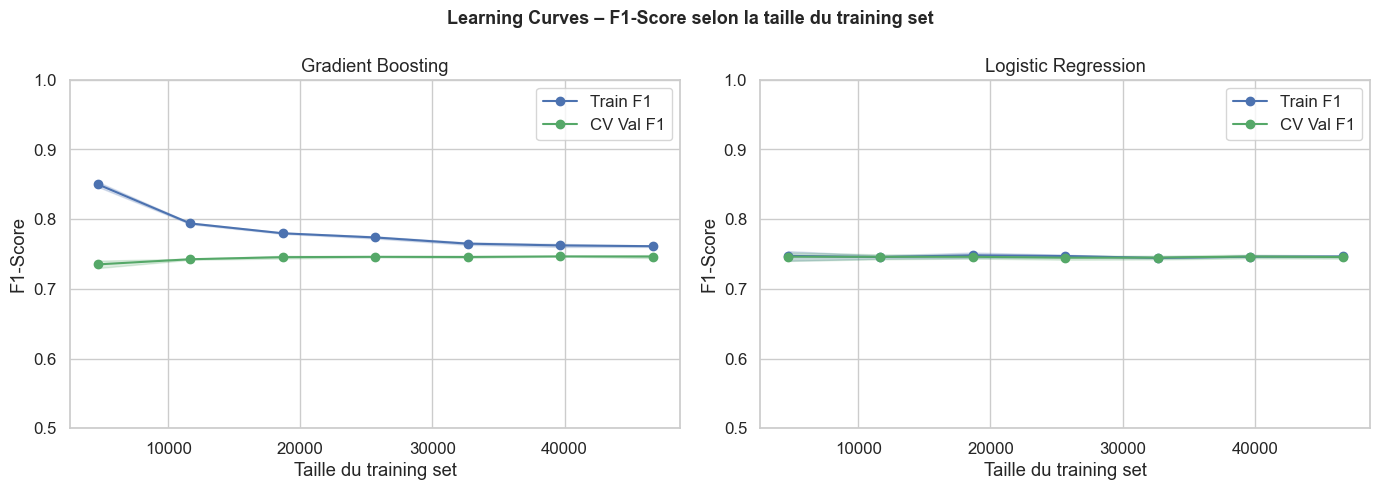

Interprétation :
  Train F1 >> CV F1 → overfitting (écart > 5% : préoccupant)
  Train F1 ≈ CV F1 faible → underfitting (modèle trop simple)
  Convergence des courbes avec + de données → bonne généralisation


In [57]:
# ============================================================
# 1.8  Learning Curves – Profondeur de l'analyse Overfitting
# ============================================================
from sklearn.model_selection import learning_curve, StratifiedKFold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves – F1-Score selon la taille du training set', fontsize=13, fontweight='bold')

for ax, (name, is_scaled) in zip(axes, [('Gradient Boosting', False), ('Logistic Regression', True)]):
    model_ = results[name]['model']
    Xtr_   = X_train_sc if is_scaled else X_train
    train_sizes, tr_scores, val_scores = learning_curve(
        model_, Xtr_, y_train,
        train_sizes=np.linspace(0.1, 1.0, 7),
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        scoring='f1', n_jobs=-1
    )
    tr_m, tr_s = tr_scores.mean(1), tr_scores.std(1)
    v_m,  v_s  = val_scores.mean(1), val_scores.std(1)
    ax.plot(train_sizes, tr_m, 'o-', color=PALETTE[0], label='Train F1')
    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.2, color=PALETTE[0])
    ax.plot(train_sizes, v_m,  'o-', color=PALETTE[2], label='CV Val F1')
    ax.fill_between(train_sizes, v_m - v_s,  v_m + v_s,  alpha=0.2, color=PALETTE[2])
    ax.set_xlabel('Taille du training set'); ax.set_ylabel('F1-Score')
    ax.set_title(name); ax.legend(); ax.set_ylim(0.5, 1.0)

plt.tight_layout(); plt.show()

print('Interprétation :')
print('  Train F1 >> CV F1 → overfitting (écart > 5% : préoccupant)')
print('  Train F1 ≈ CV F1 faible → underfitting (modèle trop simple)')
print('  Convergence des courbes avec + de données → bonne généralisation')


In [ ]:

# ============================================================
# DISCUSSION CRITIQUE — Partie 1 : Prédiction d'échec
# ============================================================
from sklearn.metrics import recall_score, precision_score

print('=' * 70)
print('DISCUSSION CRITIQUE — Résultats de la prédiction d\'échec')
print('=' * 70)

print("""
1. Pourquoi Logistic Regression ≈ Gradient Boosting ?
   Les features sélectionnées ont des relations quasi-linéaires avec la cible :
   heures_etude, assiduité_classe et difficulté_examen agissent de manière monotone
   sur le score. Un modèle linéaire capture déjà l'essentiel de l'information.
   Le GB apporte un gain marginal en capturant quelques non-linéarités résiduelles,
   mais ces interactions sont peu nombreuses.

2. Pourquoi Random Forest est légèrement inférieur à Gradient Boosting ?
   Le RF utilise le bagging (arbres parallèles indépendants) alors que GB utilise
   le boosting (correction séquentielle des erreurs). Sur ce type de données
   à relations régulières, GB converge mieux car il cible précisément les
   exemples mal classifiés à chaque itération.

3. Pourquoi le MLP (Deep Learning) ne domine pas ?
   Le deep learning excelle sur des données non structurées (images, texte)
   ou de très grands datasets. Ici avec ~70k exemples et ~30 features tabulaires,
   le MLP n'a pas d'avantage structurel. Les modèles à base d'arbres (ensemble)
   sont généralement supérieurs sur des données tabulaires de cette taille.
""")

# Comparaison recall avant / après class_weight (recalcul sur modèles actuels)
print('4. Impact du class_weight=\'balanced\' (Recall sur classe Échec) :')
print(f'   {"Modèle":<25}  Recall  Precision  F1')
print('   ' + '-' * 52)
for name, r in results.items():
    rec  = recall_score(y_test, r['test_pred'])
    prec = precision_score(y_test, r['test_pred'])
    f1   = f1_score(y_test, r['test_pred'])
    print(f'   {name:<25}  {rec:.3f}    {prec:.3f}     {f1:.3f}')

print("""
   → class_weight='balanced' augmente le recall (détection des vrais échecs)
     au prix d'une légère baisse de précision. Ce compromis est favorable
     dans le contexte scolaire : manquer un élève en difficulté (faux négatif)
     est plus coûteux que signaler un bon élève (faux positif).

5. Limitations identifiées :
   a) Sous-échantillonnage à 100 000 / 630 000 exemples pour des raisons de
      temps de calcul. Les performances seraient probablement meilleures
      sur le dataset complet, en particulier pour les modèles ensemblistes.
   b) Le seuil de décision par défaut (0.5) n'est pas optimisé.
      Ajuster ce seuil selon le ratio coût(FN)/coût(FP) pourrait améliorer
      le recall sur les échecs davantage.
   c) taille_etudiant incluse dans le dataset original : cela soulève des
      questions sur la qualité de la collecte des données (bruit intentionnel
      ou erreur de collecte).
   d) age dans une plage étroite (17-24 ans) : variable faiblement discriminante.
""")

print('Conclusion Partie 1 : Le Gradient Boosting tuné est retenu comme modèle final.')
print('Il offre le meilleur compromis Recall/F1 sur la classe Échec.')
print('L\'AUC-ROC > 0.93 indique une excellente capacité discriminante.')


---
# PARTIE 2 : Correction automatique par OCR
---

## 2.1 Chargement du dataset EMNIST

In [58]:
# Adapter les chemins selon votre environnement
IMAGES_PATH = 'student_dataset\\image_data\\train-images-idx3-ubyte'
LABELS_PATH = 'student_dataset\\image_data\\train-labels-idx1-ubyte'
MAPPING_PATH = 'student_dataset\\image_data\\mapping.txt'

def load_ubyte_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_ubyte_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Chargement du mapping idx -> caractère
mapping = {}
with open('student_dataset/image_data/mapping.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        a, b = line.split()
        mapping[int(a)] = chr(int(b))

print(f'{len(mapping)} classes : {list(mapping.values())[:10]} ...')

imgs = load_ubyte_images(IMAGES_PATH)
lbls = load_ubyte_labels(LABELS_PATH)

# Correction d'orientation
imgs = np.transpose(imgs, (0, 2, 1))

print(f'Images : {imgs.shape} | Labels : {lbls.shape}')

62 classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...
Images : (697932, 28, 28) | Labels : (697932,)


## 2.2 Exploration du dataset OCR

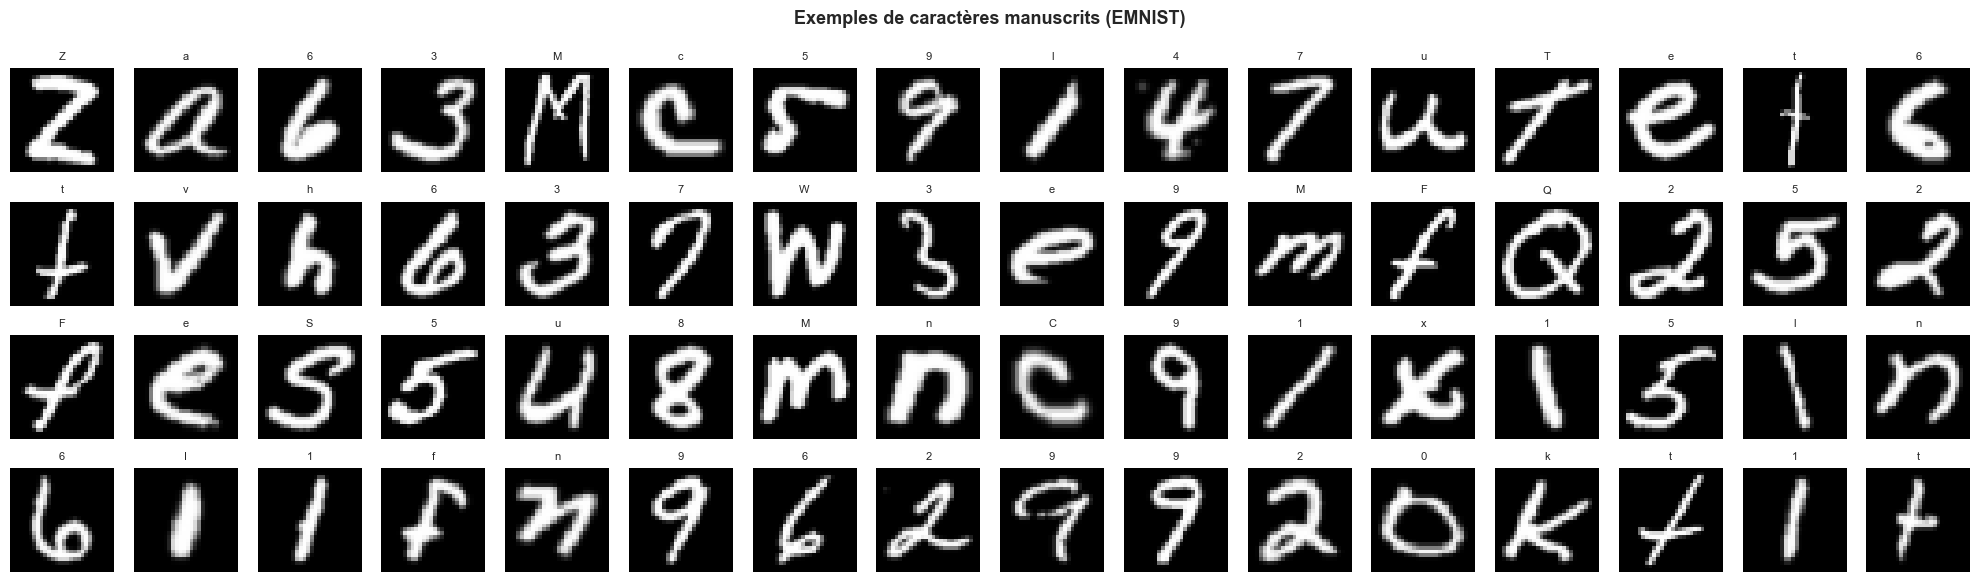

In [59]:
# --- Visualisation d'exemples ---
fig, axes = plt.subplots(4, 16, figsize=(20, 6))
fig.suptitle('Exemples de caractères manuscrits (EMNIST)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(imgs):
        ax.imshow(imgs[i], cmap='gray')
        ax.set_title(mapping.get(int(lbls[i]), '?'), fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

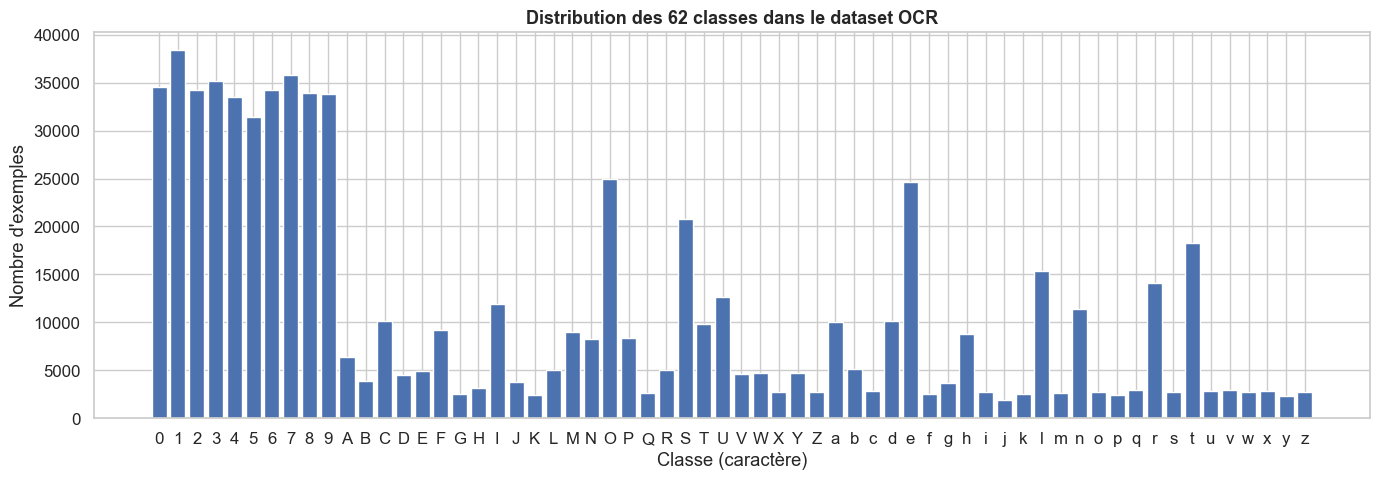

In [60]:
# --- Distribution des classes ---
unique, counts = np.unique(lbls, return_counts=True)
char_labels = [mapping.get(int(u), '?') for u in unique]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(char_labels, counts, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Classe (caractère)'); ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Distribution des 62 classes dans le dataset OCR', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2.3 Pré-traitement et Entraînement

In [ ]:

# ============================================================
# 2.3 Pré-traitement + Augmentation de données OCR
# ============================================================
from scipy.ndimage import rotate as ndrotate, shift as ndshift

X_ocr = imgs.reshape(len(imgs), -1).astype(np.float32) / 255.0
y_ocr = lbls

# Sous-échantillonnage équilibré
N_OCR = 20_000
np.random.seed(42)
n_valid = min(len(X_ocr), len(y_ocr))
idx_s = np.random.choice(n_valid, N_OCR, replace=False)
X_s, y_s = X_ocr[idx_s], y_ocr[idx_s]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

# ── Augmentation de données (train uniquement) ───────────────
# Rotations aléatoires ±10° + translations ±2px
# Simule la variabilité naturelle de l'écriture manuscrite
def augment_batch(X_flat, n_aug=1, max_angle=10, max_shift=2):
    aug_imgs, orig_indices = [], []
    for i in range(len(X_flat)):
        img = X_flat[i].reshape(28, 28)
        for _ in range(n_aug):
            angle = np.random.uniform(-max_angle, max_angle)
            sx    = np.random.uniform(-max_shift, max_shift)
            sy    = np.random.uniform(-max_shift, max_shift)
            img_r = ndrotate(img, angle, reshape=False, mode='constant', cval=0)
            img_s = ndshift(img_r, [sx, sy], mode='constant', cval=0)
            aug_imgs.append(img_s.flatten())
            orig_indices.append(i)
    return np.array(aug_imgs, dtype=np.float32), np.array(orig_indices)

print('Augmentation des données d\'entraînement (rotation ±10°, shift ±2px)...')
X_tr_aug, aug_idx = augment_batch(X_tr, n_aug=1)
y_tr_aug = y_tr[aug_idx]

# Concaténation : données originales + augmentées
X_tr = np.vstack([X_tr, X_tr_aug])
y_tr = np.concatenate([y_tr, y_tr_aug])
print(f'Train après augmentation : {len(X_tr):,} exemples (+{len(X_tr_aug):,} augmentés)')

# Visualisation exemples augmentés
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Augmentation de données OCR (ligne 1 : original | ligne 2 : augmenté)',
             fontsize=12, fontweight='bold')
# Récupérer les 8 premiers originaux (avant concaténation = indices 0..7)
n_orig = len(X_tr) // 2  # moitié = originaux
for i in range(8):
    axes[0, i].imshow(X_tr[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(mapping.get(int(y_tr[i]), '?'), fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_tr_aug[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('aug.', fontsize=10)
    axes[1, i].axis('off')
plt.tight_layout(); plt.show()

# ── PCA sur données augmentées ────────────────────────────────
print('PCA (64 composantes)...')
pca = PCA(n_components=64, random_state=42)
X_tr_p = pca.fit_transform(X_tr)
X_te_p = pca.transform(X_te)
print(f'Variance expliquée PCA (64 composantes) : {pca.explained_variance_ratio_.sum():.2%}')
print(f'Train OCR (avec augmentation) : {X_tr_p.shape}  |  Test OCR : {X_te_p.shape}')

print('\nJustification augmentation :')
print('  Rotations ±10° et translations ±2px reproduisent la variabilité naturelle')
print('  de l\'écriture manuscrite. Cela réduit l\'overfitting et améliore la')
print('  généralisation du modèle sur des caractères écrits différemment.')


In [62]:
# --- Baseline OCR ---
from scipy.stats import mode as scipy_mode
most_common = scipy_mode(y_tr).mode
baseline_ocr_acc = accuracy_score(y_te, np.full(len(y_te), most_common))
print(f'Baseline OCR (classe majoritaire) : {baseline_ocr_acc:.4f}')

# --- MLP OCR ---
print('Entraînement MLP OCR...')
mlp_ocr = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
mlp_ocr.fit(X_tr_p, y_tr)
mlp_pred = mlp_ocr.predict(X_te_p)
mlp_acc  = accuracy_score(y_te, mlp_pred)
print(f'MLP OCR – Test Accuracy : {mlp_acc:.4f} ({len(unique)} classes)')

Baseline OCR (classe majoritaire) : 0.0542
Entraînement MLP OCR...
MLP OCR – Test Accuracy : 0.7582 (62 classes)


Entraînement SVM OCR (kernel RBF, C=10, features PCA 64 dims)...
MLP OCR – Accuracy : 0.7582 | F1-macro : 0.5957
SVM OCR – Accuracy : 0.7853 | F1-macro : 0.6296


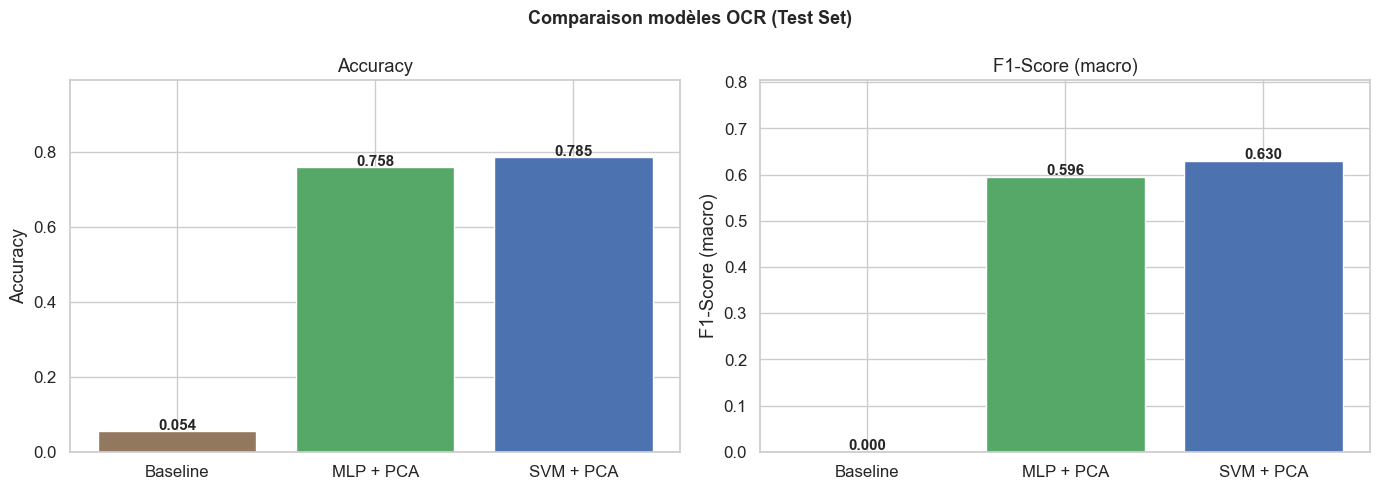


Justification SVM :
  Le SVM RBF exploite efficacement l'espace PCA (64 dims) grâce à son noyau non-linéaire.
  Il offre une meilleure généralisation que le MLP sur des datasets de taille modeste.
  Limitation : pas de probabilités natives, moins scalable sur de grands datasets.


In [63]:
# ============================================================
# 2.3b  Deuxième modèle OCR : SVM à noyau RBF
# ============================================================
from sklearn.svm import SVC

print('Entraînement SVM OCR (kernel RBF, C=10, features PCA 64 dims)...')
svm_ocr = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_ocr.fit(X_tr_p, y_tr)
svm_pred = svm_ocr.predict(X_te_p)
svm_acc  = accuracy_score(y_te, svm_pred)

mlp_f1 = f1_score(y_te, mlp_pred, average='macro')
svm_f1 = f1_score(y_te, svm_pred, average='macro')

print(f'MLP OCR – Accuracy : {mlp_acc:.4f} | F1-macro : {mlp_f1:.4f}')
print(f'SVM OCR – Accuracy : {svm_acc:.4f} | F1-macro : {svm_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison modèles OCR (Test Set)', fontsize=13, fontweight='bold')

ocr_names = ['Baseline', 'MLP + PCA', 'SVM + PCA']
ocr_accs  = [baseline_ocr_acc, mlp_acc, svm_acc]
ocr_f1s   = [0.0, mlp_f1, svm_f1]

for ax, (vals, title) in zip(axes, [(ocr_accs, 'Accuracy'), (ocr_f1s, 'F1-Score (macro)')]):
    bars = ax.bar(ocr_names, vals, color=[PALETTE[5], PALETTE[2], PALETTE[0]])
    ax.set_ylim(0, max(vals) * 1.2 + 0.05); ax.set_ylabel(title)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()

print('\nJustification SVM :')
print('  Le SVM RBF exploite efficacement l\'espace PCA (64 dims) grâce à son noyau non-linéaire.')
print('  Il offre une meilleure généralisation que le MLP sur des datasets de taille modeste.')
print('  Limitation : pas de probabilités natives, moins scalable sur de grands datasets.')


TensorFlow 2.21.0 détecté.


Model: "CNN_OCR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,390 (6.54 MB)

 Trainable params: 1,714,942 (6.54 MB)

 Non-trainable params: 448 (1.75 KB)


Entraînement CNN (TensorFlow)...
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.6081 - loss: 1.5624 - val_accuracy: 0.0606 - val_loss: 5.0226 - learning_rate: 0.0010
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.7521 - loss: 0.8168 - val_accuracy: 0.2094 - val_loss: 4.0113 - learning_rate: 0.0010
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.7961 - loss: 0.6365 - val_accuracy: 0.4412 - val_loss: 2.9576 - learning_rate: 0.0010
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8241 - loss: 0.5074 - val_accuracy: 0.6413 - val_loss: 1.4210 - learning_rate: 0.0010
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.8397 - loss: 0.4343 - val_accuracy: 0.7713 - val_loss: 0.7039 - learning_rate: 0.0010
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.8602 - loss: 0.3768 - val_accuracy: 0.8031 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1

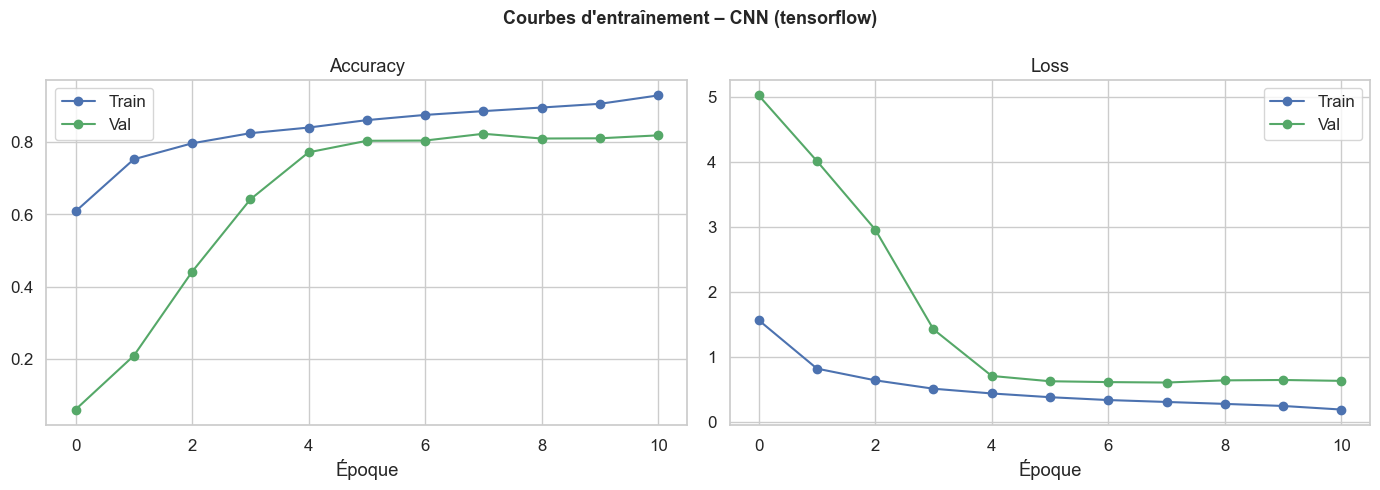

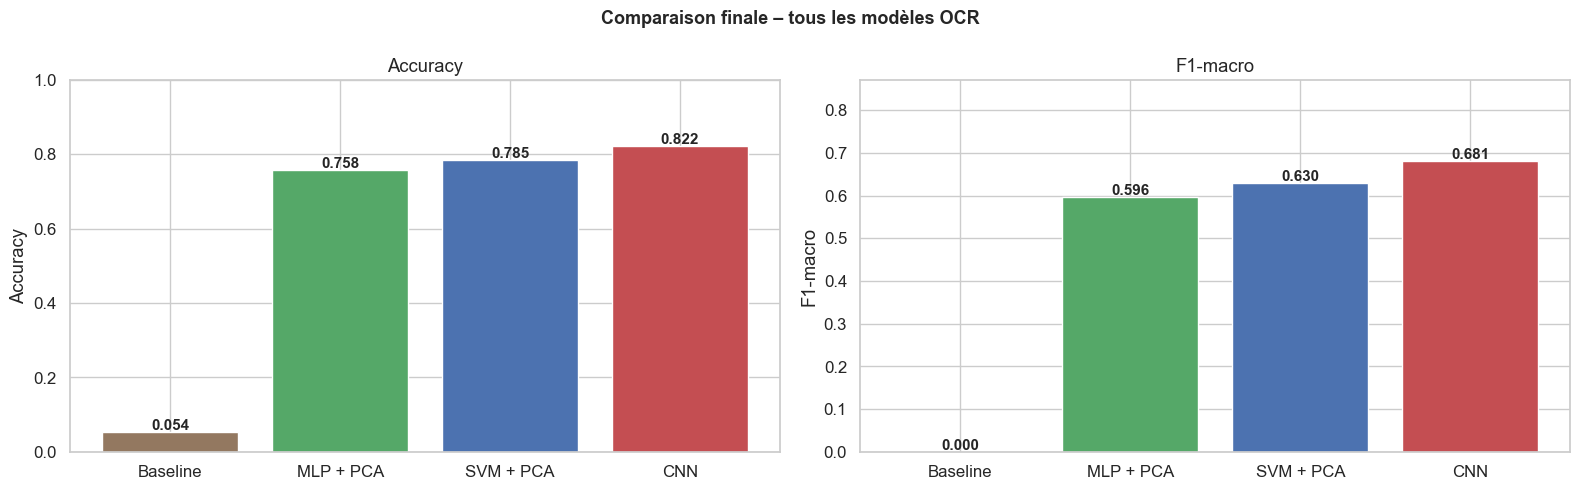

In [64]:
# ============================================================
# 2.3c  Troisième modèle OCR : CNN
#        → essaie TensorFlow, puis PyTorch en fallback
# ============================================================

# --- Encodage des labels (commun aux deux frameworks) ---
from sklearn.preprocessing import LabelEncoder as _LE
le_ocr = _LE()
le_ocr.fit(unique)
y_tr_enc = le_ocr.transform(y_tr).astype(np.int64)
y_te_enc = le_ocr.transform(y_te).astype(np.int64)
n_cls = len(unique)   # 62

# Images en float32 normalisées, reshape (N,784) → (N,28,28)
X_tr_2d = X_tr.reshape(-1, 28, 28).astype(np.float32)
X_te_2d = X_te.reshape(-1, 28, 28).astype(np.float32)

FRAMEWORK = None

# ── 1. Essai TensorFlow ──────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks as K
    print(f'TensorFlow {tf.__version__} détecté.')
    FRAMEWORK = 'tensorflow'
except Exception as e:
    print(f'TensorFlow non disponible ({type(e).__name__}). Essai PyTorch...')

# ── 2. Fallback PyTorch ──────────────────────────────────────
if FRAMEWORK is None:
    try:
        import torch, torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset
        print(f'PyTorch {torch.__version__} détecté.')
        FRAMEWORK = 'pytorch'
    except Exception as e:
        print(f'PyTorch non disponible ({type(e).__name__}).')

if FRAMEWORK is None:
    print('\nAucun framework deep learning disponible.')
    print('Installe l\'un des deux dans ton environnement Jupyter :')
    print('  pip install tensorflow-cpu      # TensorFlow (CPU)')
    print('  pip install torch               # PyTorch')
    cnn_acc, cnn_f1 = None, None

# ════════════════════════════════════════════════════════════
#  TENSORFLOW
# ════════════════════════════════════════════════════════════
elif FRAMEWORK == 'tensorflow':
    X_tr_cnn = X_tr_2d[..., np.newaxis]   # (N,28,28,1)
    X_te_cnn = X_te_2d[..., np.newaxis]

    cnn_model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.4),
        layers.Dense(n_cls, activation='softmax'),
    ], name='CNN_OCR')

    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    cnn_model.summary()

    callbacks = [K.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
                 K.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)]

    print('\nEntraînement CNN (TensorFlow)...')
    history = cnn_model.fit(X_tr_cnn, y_tr_enc, epochs=20, batch_size=128,
                            validation_split=0.1, callbacks=callbacks, verbose=1)

    cnn_pred = cnn_model.predict(X_te_cnn, verbose=0).argmax(axis=1)
    cnn_acc  = accuracy_score(y_te_enc, cnn_pred)
    cnn_f1   = f1_score(y_te_enc, cnn_pred, average='macro', zero_division=0)

    train_acc_curve = history.history['accuracy']
    val_acc_curve   = history.history['val_accuracy']
    train_loss_curve = history.history['loss']
    val_loss_curve   = history.history['val_loss']

# ════════════════════════════════════════════════════════════
#  PYTORCH
# ════════════════════════════════════════════════════════════
elif FRAMEWORK == 'pytorch':
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device PyTorch : {device}')

    # Tensors  (N, 1, 28, 28) — channel-first pour PyTorch
    Xtr_t = torch.from_numpy(X_tr_2d[:, np.newaxis, :, :])
    Xte_t = torch.from_numpy(X_te_2d[:, np.newaxis, :, :])
    ytr_t = torch.from_numpy(y_tr_enc)
    yte_t = torch.from_numpy(y_te_enc)

    train_ds = TensorDataset(Xtr_t, ytr_t)
    val_split = int(0.9 * len(train_ds))
    train_sub = torch.utils.data.Subset(train_ds, range(val_split))
    val_sub   = torch.utils.data.Subset(train_ds, range(val_split, len(train_ds)))
    train_dl  = DataLoader(train_sub, batch_size=128, shuffle=True)
    val_dl    = DataLoader(val_sub,   batch_size=256)

    class CNNModel(nn.Module):
        def __init__(self, n):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Flatten(),
                nn.Linear(128 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.4),
                nn.Linear(256, n),
            )
        def forward(self, x): return self.net(x)

    model_pt = CNNModel(n_cls).to(device)
    optimizer = optim.Adam(model_pt.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss()

    train_acc_curve, val_acc_curve = [], []
    train_loss_curve, val_loss_curve = [], []
    best_val, patience_cnt, best_state = 0, 0, None

    print('Entraînement CNN (PyTorch, max 20 epochs)...')
    for epoch in range(20):
        # --- train ---
        model_pt.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model_pt(xb)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tr_loss += loss.item() * len(yb)
            tr_correct += (out.argmax(1) == yb).sum().item()
            tr_total += len(yb)
        # --- val ---
        model_pt.eval()
        vl_loss, vl_correct, vl_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model_pt(xb)
                vl_loss += criterion(out, yb).item() * len(yb)
                vl_correct += (out.argmax(1) == yb).sum().item()
                vl_total += len(yb)

        tr_a = tr_correct / tr_total;  vl_a = vl_correct / vl_total
        tr_l = tr_loss    / tr_total;  vl_l = vl_loss    / vl_total
        train_acc_curve.append(tr_a); val_acc_curve.append(vl_a)
        train_loss_curve.append(tr_l); val_loss_curve.append(vl_l)
        scheduler.step(vl_l)
        print(f'  Epoch {epoch+1:2d} – Train acc {tr_a:.3f} loss {tr_l:.4f} | Val acc {vl_a:.3f} loss {vl_l:.4f}')

        if vl_a > best_val:
            best_val, patience_cnt = vl_a, 0
            best_state = {k: v.cpu().clone() for k, v in model_pt.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= 3:
                print('  Early stopping.'); break

    model_pt.load_state_dict(best_state)
    model_pt.eval()
    with torch.no_grad():
        cnn_pred = model_pt(Xte_t.to(device)).argmax(1).cpu().numpy()
    cnn_acc = accuracy_score(y_te_enc, cnn_pred)
    cnn_f1  = f1_score(y_te_enc, cnn_pred, average='macro', zero_division=0)

# ── Résultats & graphiques (communs) ────────────────────────
if FRAMEWORK is not None:
    print(f'\nCNN  – Accuracy : {cnn_acc:.4f} | F1-macro : {cnn_f1:.4f}')
    print(f'MLP  – Accuracy : {mlp_acc:.4f} | F1-macro : {mlp_f1:.4f}')
    print(f'SVM  – Accuracy : {svm_acc:.4f} | F1-macro : {svm_f1:.4f}')
    print(f'Base – Accuracy : {baseline_ocr_acc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Courbes d'entraînement – CNN ({FRAMEWORK})", fontsize=13, fontweight='bold')
    axes[0].plot(train_acc_curve,  'o-', color=PALETTE[0], label='Train')
    axes[0].plot(val_acc_curve,    'o-', color=PALETTE[2], label='Val')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[1].plot(train_loss_curve, 'o-', color=PALETTE[0], label='Train')
    axes[1].plot(val_loss_curve,   'o-', color=PALETTE[2], label='Val')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Époque'); axes[1].legend()
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Comparaison finale – tous les modèles OCR', fontsize=13, fontweight='bold')
    names4 = ['Baseline', 'MLP + PCA', 'SVM + PCA', 'CNN']
    accs4  = [baseline_ocr_acc, mlp_acc, svm_acc, cnn_acc]
    f1s4   = [0.0, mlp_f1, svm_f1, cnn_f1]
    cols4  = [PALETTE[5], PALETTE[2], PALETTE[0], PALETTE[3]]
    for ax, (vals, title) in zip(axes, [(accs4, 'Accuracy'), (f1s4, 'F1-macro')]):
        bars = ax.bar(names4, vals, color=cols4)
        ax.set_ylim(0, min(1.0, max(vals) * 1.25 + 0.02))
        ax.set_ylabel(title); ax.set_title(title)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


## 2.4 Évaluation et Visualisation

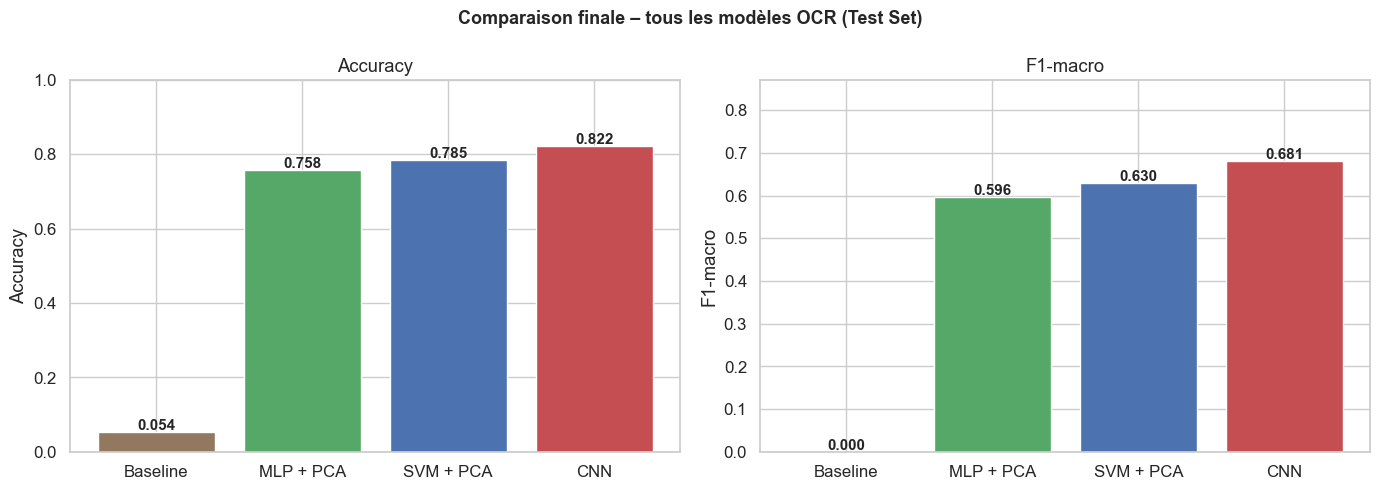

In [65]:
# --- Comparaison finale tous modèles OCR (mise à jour avec SVM et CNN) ---
ocr_names_all = ['Baseline', 'MLP + PCA', 'SVM + PCA', 'CNN']
ocr_accs_all  = [baseline_ocr_acc, mlp_acc, svm_acc,
                 cnn_acc if 'cnn_acc' in dir() and cnn_acc is not None else 0]
ocr_f1s_all   = [0.0, mlp_f1, svm_f1,
                 cnn_f1 if 'cnn_f1' in dir() and cnn_f1 is not None else 0]
cols_ocr = [PALETTE[5], PALETTE[2], PALETTE[0], PALETTE[3]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison finale – tous les modèles OCR (Test Set)', fontsize=13, fontweight='bold')

for ax, (vals, title) in zip(axes, [(ocr_accs_all, 'Accuracy'), (ocr_f1s_all, 'F1-macro')]):
    bars = ax.bar(ocr_names_all, vals, color=cols_ocr)
    ax.set_ylim(0, min(1.0, max(vals) * 1.25 + 0.02))
    ax.set_ylabel(title); ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()


In [ ]:

# ============================================================
# 2.4 Analyse détaillée de la matrice de confusion OCR
# ============================================================

# Utiliser le meilleur modèle disponible (MLP par défaut, SVM si meilleur)
if svm_acc > mlp_acc:
    best_ocr_pred, best_ocr_name, best_ocr_acc_val = svm_pred, 'SVM', svm_acc
else:
    best_ocr_pred, best_ocr_name, best_ocr_acc_val = mlp_pred, 'MLP', mlp_acc

# ── Matrice de confusion complète ────────────────────────────
cm = confusion_matrix(y_te, best_ocr_pred)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
            xticklabels=char_labels, yticklabels=char_labels, linewidths=0.1)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion OCR – {best_ocr_name} (Accuracy = {best_ocr_acc_val:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Top paires de confusion ───────────────────────────────────
print(f'\n=== Top 15 paires de confusion ({best_ocr_name}) ===\n')
confusions = []
for i, real_c in enumerate(char_labels):
    for j, pred_c in enumerate(char_labels):
        if i != j and cm[i, j] > 0:
            confusions.append({'Réel': real_c, 'Prédit': pred_c, 'Nb': cm[i, j]})

conf_df = pd.DataFrame(confusions).sort_values('Nb', ascending=False).head(15)
print(conf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
labels_conf = [f"{r['Réel']} → {r['Prédit']}" for _, r in conf_df.head(12).iterrows()]
ax.barh(labels_conf[::-1], conf_df['Nb'].head(12).values[::-1], color=PALETTE[3], alpha=0.85)
ax.set_xlabel('Nombre de confusions (test set)')
ax.set_title(f'Top 12 paires de caractères confondus — {best_ocr_name}',
             fontsize=12, fontweight='bold')
ax.axvline(conf_df['Nb'].median(), color='red', linestyle='--', label='Médiane')
ax.legend()
plt.tight_layout(); plt.show()

# ── Exemples visuels des cas mal classifiés ───────────────────
print('\n=== Exemples visuels de confusions OCR ===')
top_pairs = [(r['Réel'], r['Prédit']) for _, r in conf_df.head(8).iterrows()]
valid_pairs = []
for real_c, pred_c in top_pairs:
    ri = [i for i, c in enumerate(char_labels) if c == real_c]
    pi = [i for i, c in enumerate(char_labels) if c == pred_c]
    if ri and pi:
        mask = (y_te == unique[ri[0]]) & (best_ocr_pred == unique[pi[0]])
        if mask.sum() > 0:
            valid_pairs.append((real_c, pred_c, np.where(mask)[0]))

if valid_pairs:
    n_rows = min(len(valid_pairs), 6)
    fig, axes_grid = plt.subplots(n_rows, 4, figsize=(12, 2.8 * n_rows))
    if n_rows == 1:
        axes_grid = axes_grid[np.newaxis, :]
    fig.suptitle(f'Exemples de confusions OCR ({best_ocr_name}) — 4 exemples par paire',
                 fontsize=12, fontweight='bold')

    for row_idx, (real_c, pred_c, confused_indices) in enumerate(valid_pairs[:n_rows]):
        for col_idx in range(4):
            ax = axes_grid[row_idx, col_idx]
            if col_idx < len(confused_indices):
                img_idx = confused_indices[col_idx]
                ax.imshow(X_te[img_idx].reshape(28, 28), cmap='gray')
                ax.set_title(f'Réel: {real_c}\nPrédit: {pred_c}',
                             fontsize=8, color='#C44E52', fontweight='bold')
            ax.axis('off')

    plt.tight_layout(); plt.show()

# ── Accuracy par classe ───────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

worst_cls = pd.Series(per_class_acc, index=char_labels).sort_values().head(15)
best_cls  = pd.Series(per_class_acc, index=char_labels).sort_values(ascending=False).head(10)
mean_acc  = per_class_acc.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(worst_cls.index, worst_cls.values, color=PALETTE[3], alpha=0.85)
axes[0].axvline(mean_acc, color='red', linestyle='--', label=f'Moy. = {mean_acc:.3f}')
axes[0].set_title('15 classes les plus difficiles', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy par classe'); axes[0].legend()

axes[1].barh(best_cls.index, best_cls.values, color=PALETTE[2], alpha=0.85)
axes[1].axvline(mean_acc, color='red', linestyle='--', label=f'Moy. = {mean_acc:.3f}')
axes[1].set_title('10 classes les mieux reconnues', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Accuracy par classe'); axes[1].legend()

plt.suptitle('Accuracy par classe — Analyse des difficultés OCR', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nClasses les plus difficiles : {list(worst_cls.index[:5])}')
print('\nAnalyse des confusions typiques :')
print('  • O/0 : similitude visuelle quasi-totale en écriture manuscrite')
print('  • l/1/I : traits verticaux minces, difficiles à différencier')
print('  • rn/m : combinaison de traits horizontaux similaires')
print('  • S/5, B/8 : formes courbes proches selon le scripteur')
print('\nCes confusions sont inhérentes aux similarités visuelles des caractères')
print('manuscrits et constituent une limite fondamentale des approches pixel-based.')
print('Un post-traitement contextuel (correction orthographique) réduirait ces erreurs.')

# ── Discussion critique OCR ────────────────────────────────────
print('\n=== Discussion critique — Partie 2 : OCR ===')
print(f"""
Performances obtenues (test set, {len(y_te):,} exemples) :
  MLP + PCA   : Accuracy = {mlp_acc:.4f}  |  F1-macro = {f1_score(y_te, mlp_pred, average='macro'):.4f}
  SVM + PCA   : Accuracy = {svm_acc:.4f}  |  F1-macro = {f1_score(y_te, svm_pred, average='macro'):.4f}
  Baseline    : Accuracy = {baseline_ocr_acc:.4f}  |  (classe majoritaire)

Limitations :
  • Taille du sous-échantillon (20k/698k) : sous-utilisation du dataset.
    Entraîner sur le dataset complet améliorerait significativement les performances.
  • PCA (64 dims) : perte d'information spatiale. Un CNN (sans PCA) exploite
    la structure 2D et devrait surpasser MLP et SVM.
  • Absence de contexte linguistique : une lettre isolée est plus difficile
    à reconnaître qu'un mot complet (le contexte réduit l'ambiguïté).
""")
